# Buildbot Analysis for LLM Paper: Engagement Data (T7)
This notebook analyzes the qualitative assessments of children's interactions with the LLM (Marty) at timepoint T7.
Variables analyzed:
1. LLM_enjoyment: How did you like your last voice interaction with Marty? (1-5)
2. LLM_learning: How much did your last conversation with Marty help you learn? (1-5)
3. LLM_contributions: Did you feel everyone talked to Marty equally? (1-4)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 12

In [4]:
# Load data with ISO-8859-1 encoding
data_path = Path('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv')
df = pd.read_csv(data_path, encoding='ISO-8859-1')

# Filter for T7 (Post-session LLM interaction)
df_t7 = df[df['Timepoint'] == 'T7'].copy()

print(f"Total responses at T7: {len(df_t7)}")
df_t7[['LLM_enjoyment', 'LLM_learning', 'LLM_contributions']].describe()

Total responses at T7: 26


,LLM_enjoyment,LLM_learning,LLM_contributions
count,26.000000,26.000000,26.000000
mean,3.961538,3.269231,2.730769
std,0.915675,1.115623,0.874423
min,2.000000,1.000000,1.000000
25%,4.000000,3.000000,2.000000
50%,4.000000,3.000000,3.000000
75%,4.750000,4.000000,3.000000
max,5.000000,5.000000,4.000000


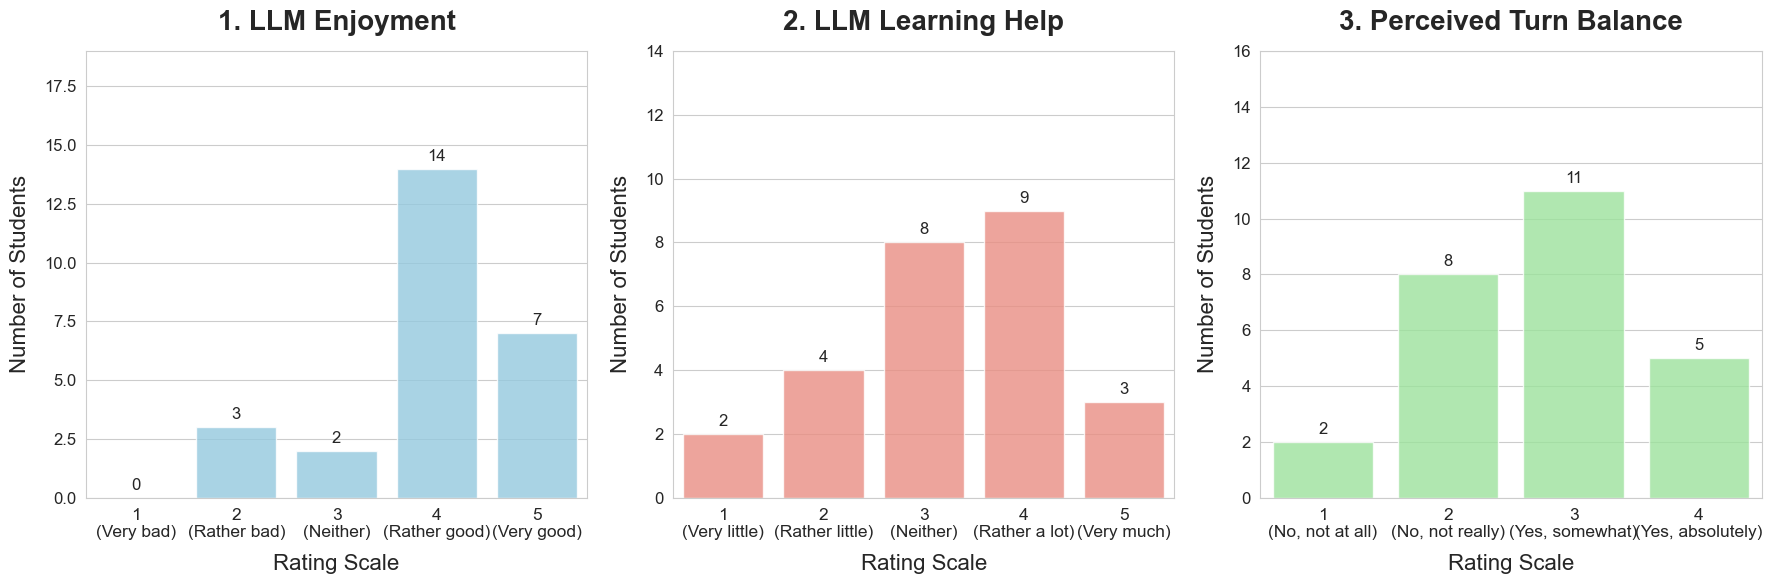

In [5]:
# Define qualitative labels for our 3 metrics
enjoyment_labels = {1: 'Very bad', 2: 'Rather bad', 3: 'Neither', 4: 'Rather good', 5: 'Very good'}
learning_labels = {1: 'Very little', 2: 'Rather little', 3: 'Neither', 4: 'Rather a lot', 5: 'Very much'}
contribution_labels = {1: 'No, not at all', 2: 'No, not really', 3: 'Yes, somewhat', 4: 'Yes, absolutely'}

def plot_distribution(data, column, title, labels_map, color, subplot_idx):
    plt.subplot(1, 3, subplot_idx)
    
    # Ensure all scale points (1-5 or 1-4) are shown, even if they have 0 counts
    possible_values = sorted(labels_map.keys())
    counts = data[column].value_counts().reindex(possible_values).fillna(0)
    
    # Create the bar plot
    ax = sns.barplot(x=counts.index, y=counts.values, color=color, alpha=0.8)
    
    plt.title(title, fontweight='bold', pad=15, fontsize=20)
    plt.xlabel('Rating Scale', fontsize=16, labelpad=10)
    plt.ylabel('Number of Students', fontsize=16, labelpad=10)
    plt.ylim(0, counts.max() + 5) # Add space for labels
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    
    # Replace numeric ticks with our qualitative labels
    plt.xticks(ticks=range(len(possible_values)), 
               labels=[f"{v}\n({labels_map[v]})" for v in possible_values], 
               fontsize=12.5)

# Create the 3-panel figure
plt.figure(figsize=(18, 6))

plot_distribution(df_t7, 'LLM_enjoyment', '1. LLM Enjoyment', enjoyment_labels, 'skyblue', 1)
plot_distribution(df_t7, 'LLM_learning', '2. LLM Learning Help', learning_labels, 'salmon', 2)
plot_distribution(df_t7, 'LLM_contributions', '3. Perceived Turn Balance', contribution_labels, 'lightgreen', 3)

plt.tight_layout()
plt.savefig('llm_interaction_distributions_t7.png', dpi=300, bbox_inches='tight')
plt.show()

The analysis of the 26 student responses at timepoint T2 reveals the following average ratings:

- **Mean Enjoyment**: `3.96` (Close to "Rather good")
- **Mean Learning Help**: `3.27` (Above "Neither")
- **Mean Perceived Equality**: `2.73` (Between "No, not really" and "Yes, somewhat")

## Summary of Findings (T2)



In [6]:
# --- DATA LOADING FOR INTEGRATED ANALYSIS ---
# This file contains the turn counts, off-topic counts, and co-creation levels
analysis_path = Path('Data/BuildbotAnalysis - LLM analysis.csv')

# We skip the first row because it contains merged category headers
df_analysis = pd.read_csv(analysis_path, skiprows=1)

# Clean up column names (removing newlines and extra spaces)
df_analysis.columns = [col.replace('\n', ' ').strip() for col in df_analysis.columns]

print(f"Loaded integrated analysis for {len(df_analysis)} groups.")
df_analysis.head(3)

Loaded integrated analysis for 11 groups.


,Group,Luca's comments on the frame,"I enjoyed the activity (in T7, average)",I found the activity very interesting (in T7 average),"LLM_enjoyment: How did you like your last voice interaction with Marty? Very bad (1), Rather bad, Neither, Rather good, Very good (5)","LLM_learning: How much did your last conversation with Marty help you learn about microcontrollers?Very little (1), Rather little, Neither, Rather a lot, Very much (5)","LLM_contributions: Did you feel that everyone in your group talked/wrote to Marty equally?No, not at all (1); No, not really; Yes, somewhat; Yes, absolutely (4)",Students' feedback: Positives,Students' feedback: Negatives,average nb of correct answers on LLM_Microcontollers (out of 8),...,Non relevant contributions,Number of relevant contributions,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",Number of concepts that went from flagged misunderstanding/confusions to correct concepts,No Frame: student 1,No Frame: student 2,No Frame: student 3,With Frame: student 1,With Frame: student 2,With Frame: student 3
0,1,Data loss,4.33,3.00,4.33,3.67,3.67,marty talking\nthe speaking\nprogramming\never...,building more and talk about other things\ntha...,5.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Frame never actually provided the full story b...,3.00,4.00,3.67,3.67,2.00,programming\ntalking with marty\ntalking to hi...,too little practical work\nthat he sometimes d...,7.00,...,0,NaN,3.0,NaN,13.0,0.0,NaN,7.0,4.0,NaN
2,3,Frame stopped creating story and ended convers...,3.67,3.33,3.33,3.67,3.00,speaking with marty\nthat we got a lot of info...,marty misunderstands some things\nthat we alwa...,4.33,...,**agent m**: What do you like about microcontr...,NaN,1.0,NaN,9.0,8.0,2.0,6.0,3.0,2.0


# Nb of total turns and off topic turns

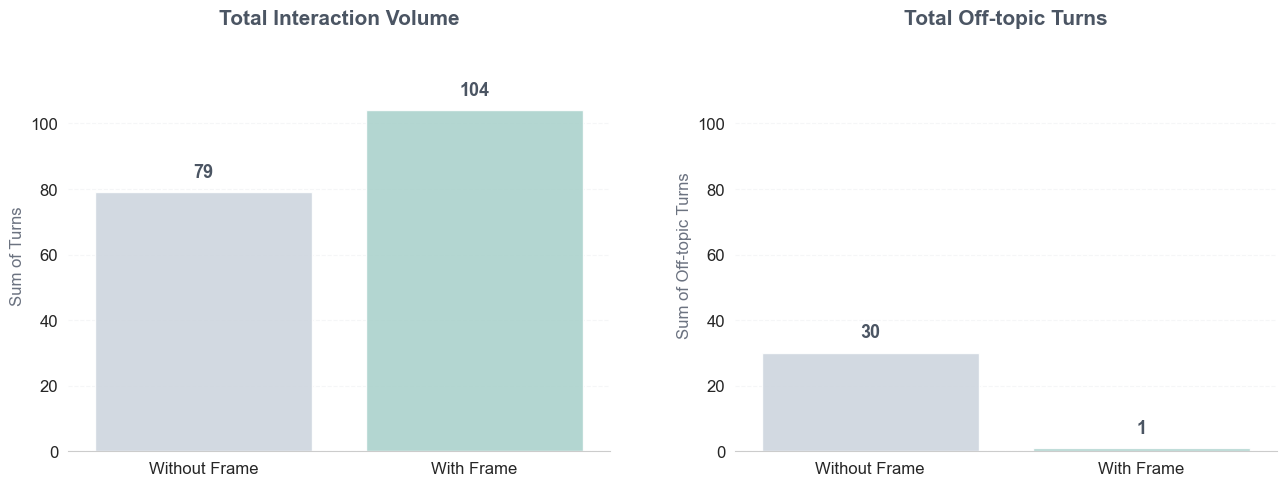

In [7]:
# --- DESIGNER PALETTE: PASTEL SLATE & SOFT AQUA ---
color_baseline = "#CBD5E1" # Pastel Slate Grey
color_frame    = "#A5D8D0" # Soft Pastel Mint/Aqua (Blue-Green shift)

# 1. Prepare data (totals)
comp_data = df_analysis[[
    'Number of Turns in Frame', 
    'Number of Turns in No Frame', 
    'Out of topic turns  with frame', 
    'Out of topic turns without Frame'
]].dropna()

totals = {
    'Turns (No Frame)': comp_data['Number of Turns in No Frame'].sum(),
    'Turns (With Frame)': comp_data['Number of Turns in Frame'].sum(),
    'Off-topic (No Frame)': comp_data['Out of topic turns without Frame'].sum(),
    'Off-topic (With Frame)': comp_data['Out of topic turns  with frame'].sum()
}

# Calculate the maximum value across ALL bars to set a uniform scale
all_values = list(totals.values())
max_val = max(all_values)
upper_limit = max_val * 1.15 # Add 15% head room for the numeric labels

# 2. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Total Number of Turns
turn_categories = ['Without Frame', 'With Frame']
turn_values = [totals['Turns (No Frame)'], totals['Turns (With Frame)']]

sns.barplot(x=turn_categories, y=turn_values, hue=turn_categories, 
            palette=[color_baseline, color_frame], ax=ax1, alpha=0.9, legend=False)

ax1.set_title("Total Interaction Volume", fontweight='bold', fontsize=15, pad=25, color='#4B5563')
ax1.set_ylabel("Sum of Turns", fontsize=12, color='#6B7280')
ax1.set_ylim(0, upper_limit) # Set uniform scale
ax1.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=13, color='#4B5563')

# Subplot 2: Total Number of Off-topic Turns
off_categories = ['Without Frame', 'With Frame']
off_values = [totals['Off-topic (No Frame)'], totals['Off-topic (With Frame)']]

sns.barplot(x=off_categories, y=off_values, hue=off_categories, 
            palette=[color_baseline, color_frame], ax=ax2, alpha=0.9, legend=False)

ax2.set_title("Total Off-topic Turns", fontweight='bold', fontsize=15, pad=25, color='#4B5563')
ax2.set_ylabel("Sum of Off-topic Turns", fontsize=12, color='#6B7280')
ax2.set_ylim(0, upper_limit) # Set uniform scale
ax2.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=13, color='#4B5563')

plt.tight_layout(pad=4.0)
plt.show()

# Balanced turns with GINI

/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15552/1079946776.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_plot, x='Condition', y='Gini',


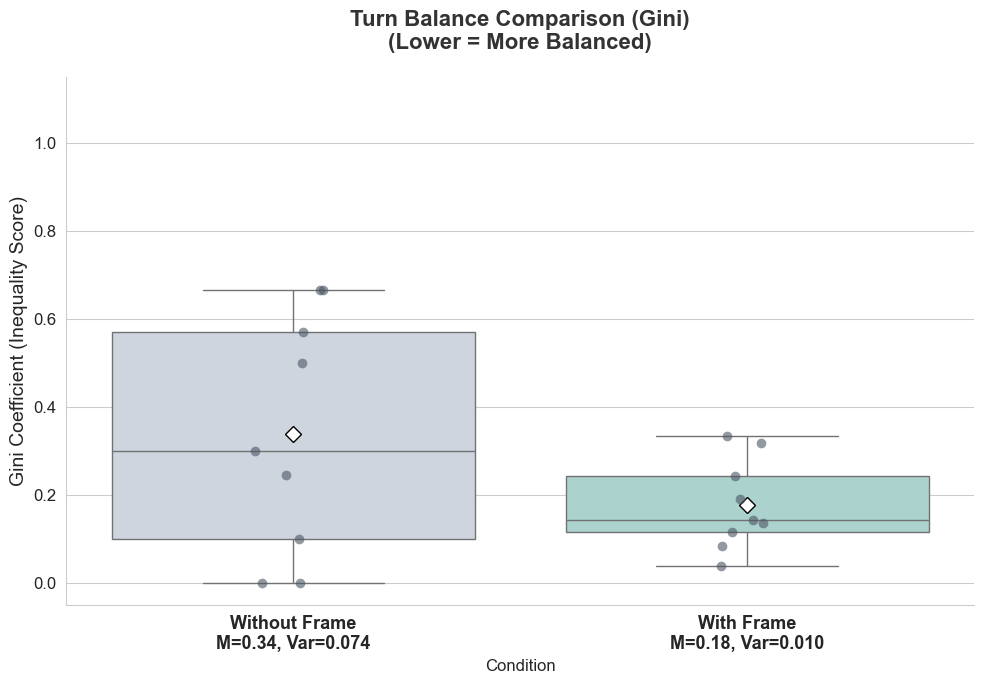

Wilcoxon test: p-value = 0.1289


In [8]:
import numpy as np
from scipy.stats import wilcoxon

# Function to calculate Gini Coefficient (Balance Score)
def gini(list_of_values):
    values = np.array(list_of_values)
    values = values[~np.isnan(values)] # Remove NA
    if len(values) == 0 or sum(values) == 0:
        return np.nan
    sorted_values = np.sort(values)
    n = len(values)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * sorted_values)) / (n * np.sum(sorted_values))

# 1. Select the last 6 columns and Group
s_cols_no = ['No Frame: student 1', 'No Frame: student 2', 'No Frame: student 3']
s_cols_with = ['With Frame: student 1', 'With Frame: student 2', 'With Frame: student 3']

# 2. Calculate Balance Scores for each condition
df_analysis['balance_no_frame'] = df_analysis[s_cols_no].apply(lambda x: gini(x), axis=1)
df_analysis['balance_with_frame'] = df_analysis[s_cols_with].apply(lambda x: gini(x), axis=1)

# Drop rows where we don't have comparison data
df_balance = df_analysis[['Group', 'balance_no_frame', 'balance_with_frame']].dropna()

# --- NEW: Calculate Stats for the Graph ---
mean_no = df_balance['balance_no_frame'].mean()
var_no = df_balance['balance_no_frame'].var()
mean_with = df_balance['balance_with_frame'].mean()
var_with = df_balance['balance_with_frame'].var()

# 3. Visualization
plt.figure(figsize=(10, 7))
color_baseline = "#CBD5E1" # Pastel Grey
color_frame    = "#A5D8D0" # Soft Aqua

# Reshape for plotting
df_plot = df_balance.melt(id_vars='Group', var_name='Condition', value_name='Gini')
df_plot['Condition'] = df_plot['Condition'].map({
    'balance_no_frame': 'Without Frame', 
    'balance_with_frame': 'With Frame'
})

# Create boxplot showing the mean as a white diamond
ax = sns.boxplot(data=df_plot, x='Condition', y='Gini', 
                 palette=[color_baseline, color_frame],
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                 legend=False)

sns.stripplot(data=df_plot, x='Condition', y='Gini', color='#4B5563', alpha=0.6, size=7)

# Update X-axis labels to include Mean and Variance
plt.xticks(ticks=[0, 1], labels=[
    f"Without Frame\nM={mean_no:.2f}, Var={var_no:.3f}",
    f"With Frame\nM={mean_with:.2f}, Var={var_with:.3f}"
], fontsize=13, fontweight='bold')

plt.title("Turn Balance Comparison (Gini)\n(Lower = More Balanced)", fontweight='bold', fontsize=16, pad=20, color='#333333')
plt.ylabel("Gini Coefficient (Inequality Score)", fontsize=14)
plt.ylim(-0.05, 1.15) # Room for labels

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Statistical Testing
stat, p = wilcoxon(df_balance['balance_no_frame'], df_balance['balance_with_frame'])
print(f"Wilcoxon test: p-value = {p:.4f}")

STATISTICAL ANALYSIS: TURN BALANCE (GINI)

1. ANOVA Result (Difference in Means):
F-statistic: 2.7659
p-value:     0.1158
RESULT: No significant difference in average balance found.

2. Levene’s Test Result (Difference in Variance):
W-statistic: 9.3570
p-value:     0.0075
RESULT: The consistency (variance) of the balance is significantly different.
        (One condition is more reliable than the other).

3. Detailed ANOVA Table:


,sum_sq,df,F,PR(>F)
Condition,0.116735,1.0,2.765868,0.115756
Residual,0.675287,16.0,NaN,NaN


/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15552/2620048129.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Condition', y='Gini', palette=[color_baseline, color_frame], inner="quart")


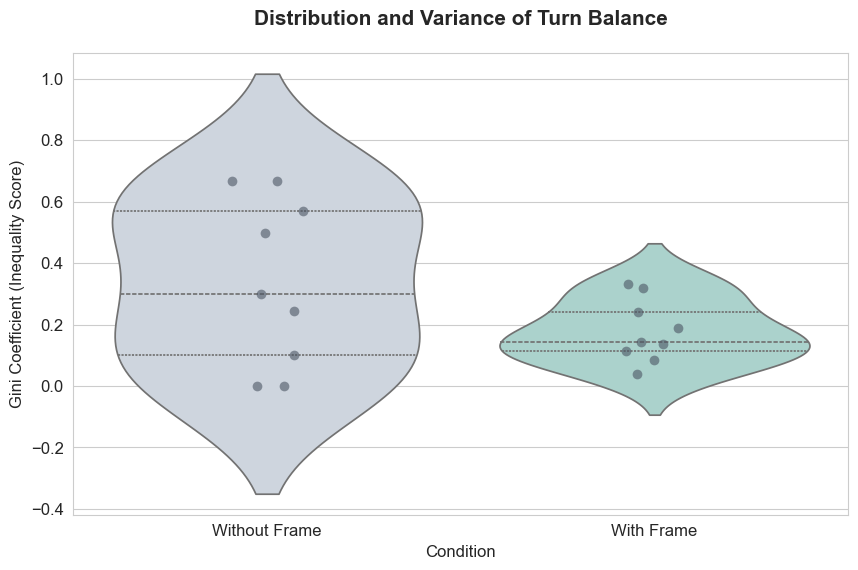

In [9]:
from scipy.stats import f_oneway, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Prepare the data
# We use the df_plot (long format) created in the previous step
# df_plot has columns: ['Group', 'Condition', 'Gini']

# 2. ANOVA (Comparing the MEANS of the balance scores)
# This tells us: "On average, is one condition more balanced than the other?"
f_stat, p_anova = f_oneway(
    df_balance['balance_no_frame'], 
    df_balance['balance_with_frame']
)

# 3. Levene's Test (Comparing the VARIANCES of the balance scores)
# This tells us: "Is the balance more CONSISTENT in one condition vs the other?"
# (i.e., do some groups struggle a lot while others succeed, or are they all similar?)
l_stat, p_levene = levene(
    df_balance['balance_no_frame'], 
    df_balance['balance_with_frame'], 
    center='median' # 'median' is recommended for non-normal data
)

# 4. Detailed ANOVA table using statsmodels
model = ols('Gini ~ Condition', data=df_plot).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# --- Output Results ---
print("="*60)
print("STATISTICAL ANALYSIS: TURN BALANCE (GINI)")
print("="*60)

print("\n1. ANOVA Result (Difference in Means):")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_anova:.4f}")
if p_anova < 0.05:
    print("RESULT: There is a significant difference in the AVERAGE turn balance.")
else:
    print("RESULT: No significant difference in average balance found.")

print("\n2. Levene’s Test Result (Difference in Variance):")
print(f"W-statistic: {l_stat:.4f}")
print(f"p-value:     {p_levene:.4f}")
if p_levene < 0.05:
    print("RESULT: The consistency (variance) of the balance is significantly different.")
    print("        (One condition is more reliable than the other).")
else:
    print("RESULT: No significant difference in the consistency (variance) found.")

print("\n3. Detailed ANOVA Table:")
display(anova_table)

# 5. Visualizing the Variance (Spread)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='Condition', y='Gini', palette=[color_baseline, color_frame], inner="quart")
sns.stripplot(data=df_plot, x='Condition', y='Gini', color='#4B5563', alpha=0.6, size=7)

plt.title("Distribution and Variance of Turn Balance", fontweight='bold', fontsize=15, pad=20)
plt.ylabel("Gini Coefficient (Inequality Score)", fontsize=12)
plt.show()

/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15552/2475212909.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_cocreation, x='Level', y='Score',


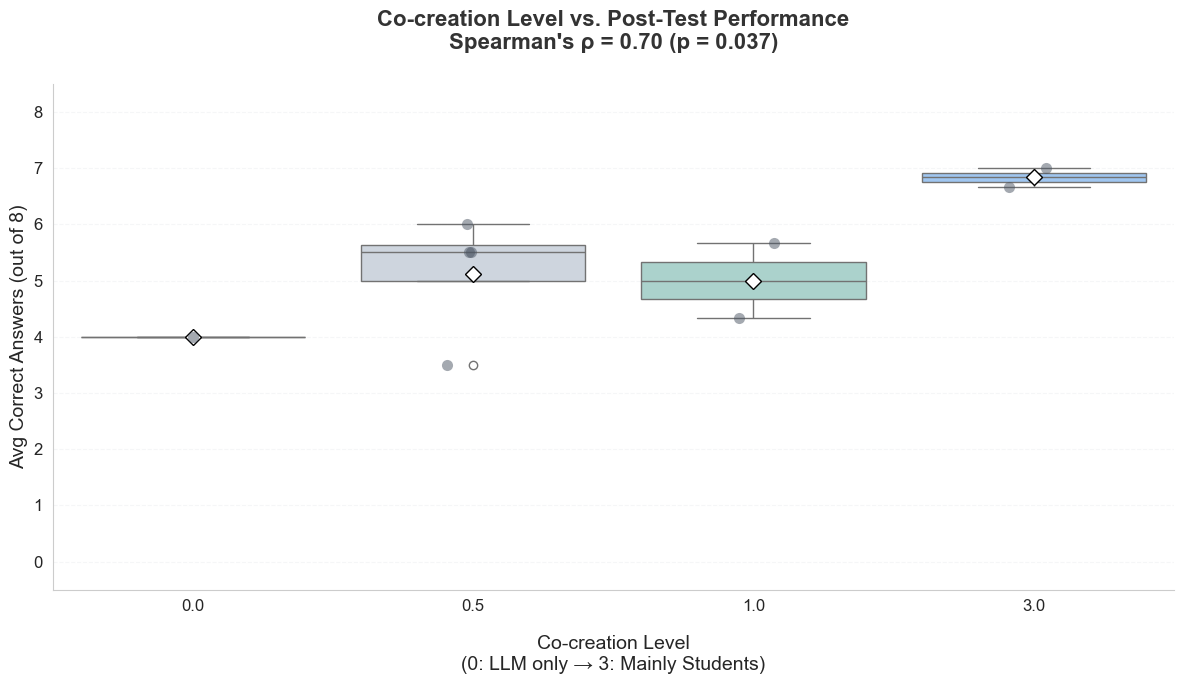

Analysis Summary:
Groups analyzed: 9
Level 0: Mean Score = 4.00 (n=1)
Level 0: Mean Score = 5.12 (n=4)
Level 1: Mean Score = 5.00 (n=2)
Level 3: Mean Score = 6.83 (n=2)


In [10]:
# 1. Prepare the data
# Using the exact long column names from your CSV
cocreation_col = "Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)"
score_col = "average nb of correct answers on LLM_Microcontollers (out of 8)"

# Extract and drop missing values
df_cocreation = df_analysis[[cocreation_col, score_col]].dropna()
df_cocreation.columns = ['Level', 'Score']

# 2. Statistical Analysis (Spearman Rank Correlation)
from scipy.stats import spearmanr
rho, p_val = spearmanr(df_cocreation['Level'], df_cocreation['Score'])

# 3. Visualization
plt.figure(figsize=(12, 7))

# Define a soft pastel sequence for the levels 0-3
pastel_palette = ["#E2E8F0", "#CBD5E1", "#A5D8D0", "#93C5FD"] 

ax = sns.boxplot(data=df_cocreation, x='Level', y='Score', 
                 palette=pastel_palette,
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                 legend=False)

# Add individual group points
sns.stripplot(data=df_cocreation, x='Level', y='Score', color='#4B5563', alpha=0.5, size=8)

# Set labels and title
plt.title(f"Co-creation Level vs. Post-Test Performance\nSpearman's ρ = {rho:.2f} (p = {p_val:.3f})", 
          fontweight='bold', fontsize=16, pad=25, color='#333333')

plt.xlabel("Co-creation Level\n(0: LLM only → 3: Mainly Students)", fontsize=14, labelpad=15)
plt.ylabel("Avg Correct Answers (out of 8)", fontsize=14)
plt.ylim(-0.5, 8.5)

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)

plt.tight_layout()
plt.show()

# Print detailed summary
print("Analysis Summary:")
print(f"Groups analyzed: {len(df_cocreation)}")
for level in sorted(df_cocreation['Level'].unique()):
    mean_score = df_cocreation[df_cocreation['Level'] == level]['Score'].mean()
    count = len(df_cocreation[df_cocreation['Level'] == level])
    print(f"Level {int(level)}: Mean Score = {mean_score:.2f} (n={count})")

/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15552/2604389134.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([level_labels.get(x, f"{x}") for x in all_x_values], fontsize=18, fontweight='bold')


Actual levels in data: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(3.0)]


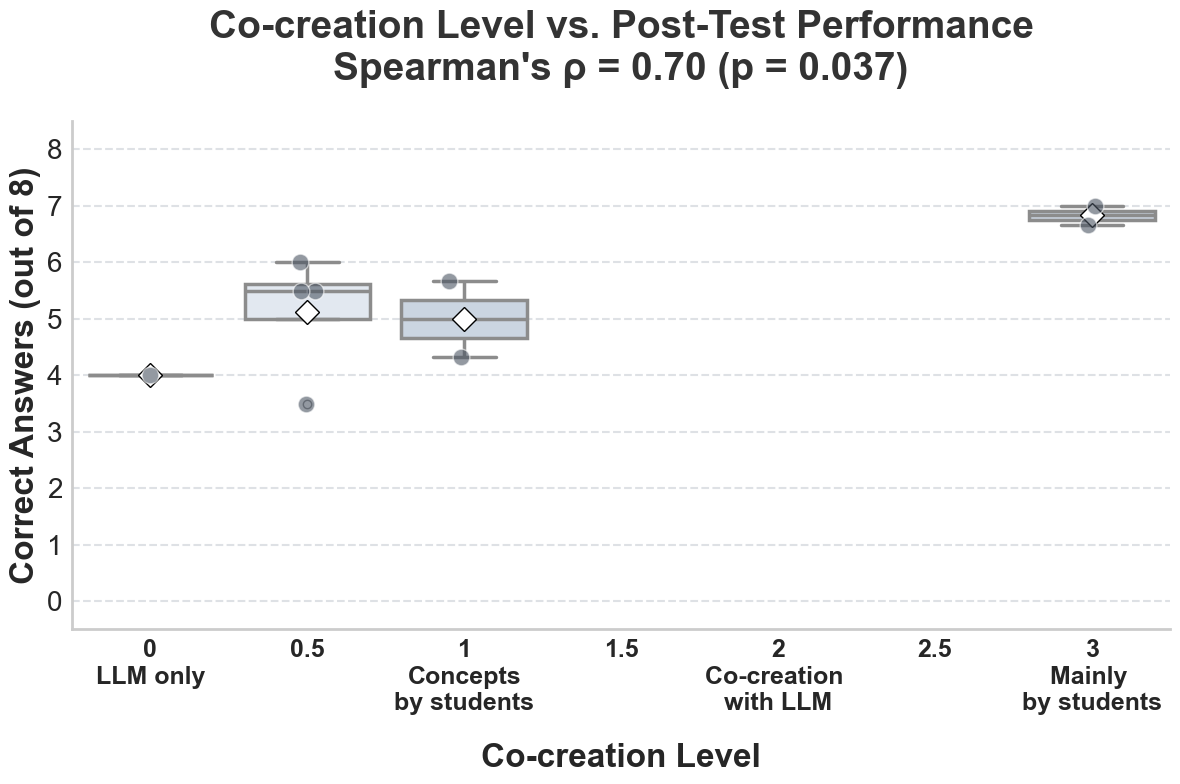


Analysis Summary:
Groups analyzed: 9
Level 0.0: Mean Score = 4.00 (n=1)
Level 0.5: Mean Score = 5.12 (n=4)
Level 1.0: Mean Score = 5.00 (n=2)
Level 1.5: No data
Level 2: No data
Level 2.5: No data
Level 3.0: Mean Score = 6.83 (n=2)


In [11]:
# 1. Prepare the data
# Using the exact long column names from your CSV
cocreation_col = "Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)"
score_col = "average nb of correct answers on LLM_Microcontollers (out of 8)"

# Extract and drop missing values
df_cocreation = df_analysis[[cocreation_col, score_col]].dropna()
df_cocreation.columns = ['Level', 'Score']

# Get all unique levels in the data
actual_levels = sorted(df_cocreation['Level'].unique())
print(f"Actual levels in data: {actual_levels}")

# Define all expected levels (including half-steps)
expected_levels = [0, 0.5, 1, 1.5, 2, 2.5, 3]

# Combine actual and expected to get full x-axis range
all_x_values = sorted(set(actual_levels) | set(expected_levels))

# 2. Statistical Analysis (Spearman Rank Correlation)
from scipy.stats import spearmanr
rho, p_val = spearmanr(df_cocreation['Level'], df_cocreation['Score'])

# 3. Define level labels - SHORT VERSION FOR SLIDES
level_labels = {
    0: "0\nLLM only",
    0.5: "0.5",
    1: "1\nConcepts\nby students",
    1.5: "1.5",
    2: "2\nCo-creation \nwith LLM",
    2.5: "2.5",
    3: "3\nMainly \nby students"
}

# 4. Visualization - OPTIMIZED FOR SLIDES
plt.figure(figsize=(12, 8))

# Define a soft pastel sequence
pastel_palette = ["#E2E8F0", "#CBD5E1", "#A5D8D0", "#93C5FD"] 

ax = sns.boxplot(data=df_cocreation, x='Level', y='Score', 
                 order=all_x_values,
                 color='#E2E8F0',
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"12"},
                 linewidth=2.5)

# Manually color the boxes with pastel palette
for i, patch in enumerate(ax.patches):
    # Map colors to the integer part of the level for consistency
    level_idx = int(all_x_values[i])
    patch.set_facecolor(pastel_palette[level_idx % len(pastel_palette)])

# Add individual group points - LARGER
sns.stripplot(data=df_cocreation, x='Level', y='Score', 
              order=all_x_values,
              color='#4B5563', alpha=0.6, size=12, linewidth=1, edgecolor='white')

# Set labels and title - MUCH LARGER TEXT
plt.title(f"Co-creation Level vs. Post-Test Performance\nSpearman's ρ = {rho:.2f} (p = {p_val:.3f})", 
          fontweight='bold', fontsize=28, pad=30, color='#333333')

plt.xlabel("Co-creation Level", fontsize=24, labelpad=20, fontweight='bold')
plt.ylabel("Correct Answers (out of 8)", fontsize=24, fontweight='bold')
plt.ylim(-0.5, 8.5)

# Set custom x-tick labels - LARGER
ax.set_xticklabels([level_labels.get(x, f"{x}") for x in all_x_values], fontsize=18, fontweight='bold')

# Y-axis ticks LARGER
ax.tick_params(axis='y', labelsize=20)

# Clean up axes - THICKER LINES
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.yaxis.grid(True, linestyle='--', which='major', color='#D1D5DB', alpha=0.7, linewidth=1.5)

plt.tight_layout()
plt.show()

# Print detailed summary
print("\nAnalysis Summary:")
print(f"Groups analyzed: {len(df_cocreation)}")
for level in all_x_values:
    level_data = df_cocreation[df_cocreation['Level'] == level]['Score']
    if len(level_data) > 0:
        mean_score = level_data.mean()
        count = len(level_data)
        print(f"Level {level}: Mean Score = {mean_score:.2f} (n={count})")
    else:
        print(f"Level {level}: No data")

Analysis for the 2 specific Microcontroller questions:
Spearman rho = 0.275
p-value      = 0.475


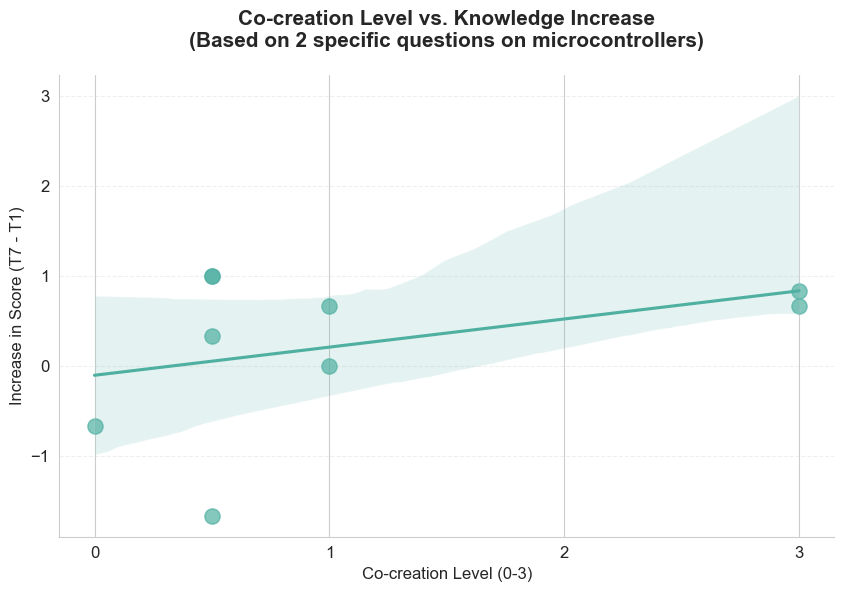

,Group,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",T1_Avg_2q,T7_Avg_2q,learning_increase_2q
0,2,3.0,0.666667,1.500000,0.833333
1,3,1.0,0.333333,1.000000,0.666667
2,4,1.0,0.333333,0.333333,0.000000
3,5,0.5,0.000000,0.333333,0.333333
4,6,3.0,0.333333,1.000000,0.666667
5,7,0.5,1.666667,0.000000,-1.666667
6,8,0.5,0.000000,1.000000,1.000000
7,9,0.5,0.000000,1.000000,1.000000
8,10,0.0,0.666667,0.000000,-0.666667


In [12]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Mapping (Participant ID -> Group)
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')

# 2. Load the Knowledge Data
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# Helper function to score the 2 specific questions (1 = correct, else 0)
def score_mc_questions(df_subset):
    return (df_subset['microcontrollers_1'] == 1).astype(int) + \
           (df_subset['microcontrollers_2'] == 1).astype(int)

# 3. Extract and Score T1 and T7 for the SAME 2 questions
# T1 Scores
df_t1 = df_children[df_children['Timepoint'] == 'T1'].copy()
df_t1['score_2q'] = score_mc_questions(df_t1)

# T7 Scores
df_t7 = df_children[df_children['Timepoint'] == 'T7'].copy()
df_t7['score_2q'] = score_mc_questions(df_t7)

# 4. Aggregate to Group Level
# Merge mapping first to get Group IDs
df_t1_grp = df_t1.merge(mapping, on='Participant ID').groupby('Group')['score_2q'].mean().reset_index()
df_t1_grp.columns = ['Group', 'T1_Avg_2q']

df_t7_grp = df_t7.merge(mapping, on='Participant ID').groupby('Group')['score_2q'].mean().reset_index()
df_t7_grp.columns = ['Group', 'T7_Avg_2q']

# Merge T1 and T7 group averages
df_growth = df_t1_grp.merge(df_t7_grp, on='Group')
df_growth['learning_increase_2q'] = df_growth['T7_Avg_2q'] - df_growth['T1_Avg_2q']

# 5. Merge with Co-creation Level from Analysis CSV
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

# Final combined dataframe
df_final_2q = df_cocreat.merge(df_growth, on='Group', how='inner')

# 6. Calculate Correlation
rho, p = spearmanr(df_final_2q[cocreation_col], df_final_2q['learning_increase_2q'])

print(f"Analysis for the 2 specific Microcontroller questions:")
print(f"Spearman rho = {rho:.3f}")
print(f"p-value      = {p:.3f}")

# 7. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final_2q, x=cocreation_col, y='learning_increase_2q', 
            scatter_kws={'s':120, 'alpha':0.7}, color='#4FB0A2')

plt.title("Co-creation Level vs. Knowledge Increase\n(Based on 2 specific questions on microcontrollers)", fontweight='bold', fontsize=15, pad=20)
plt.xlabel("Co-creation Level (0-3)", fontsize=12)
plt.ylabel("Increase in Score (T7 - T1)", fontsize=12)
plt.xticks([0, 1, 2, 3])
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.show()

display(df_final_2q[['Group', cocreation_col, 'T1_Avg_2q', 'T7_Avg_2q', 'learning_increase_2q']])

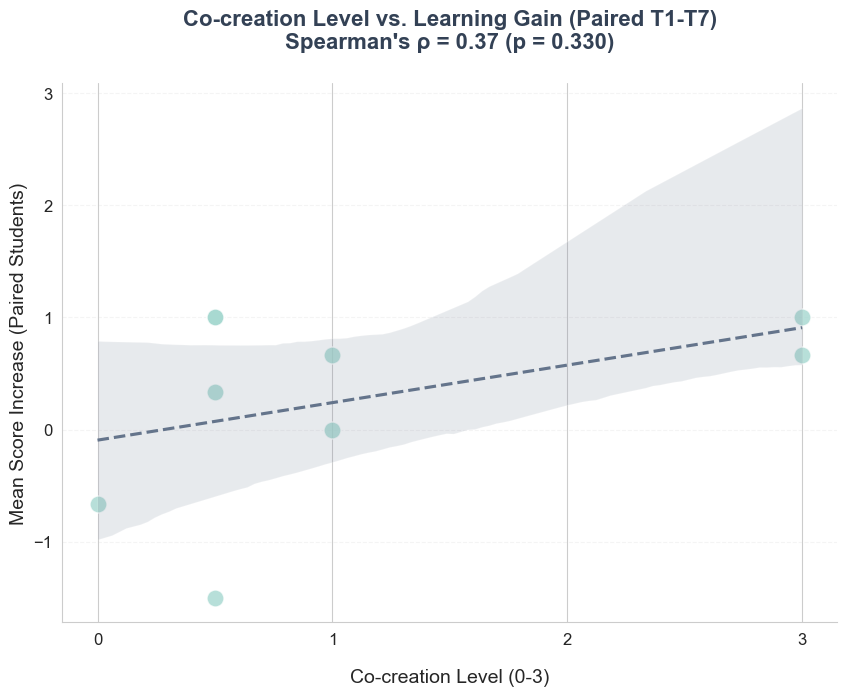

Paired students analyzed: 26
Groups included in final correlation: 9


In [13]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Clean Participant IDs
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. isolate T1 and T7 knowledge data
df_t1 = df_children[df_children['Timepoint'] == 'T1'].copy()
df_t7 = df_children[df_children['Timepoint'] == 'T7'].copy()

# Score the 2 specific questions (1 = correct, else 0)
for df_tmp in [df_t1, df_t7]:
    df_tmp['mc_score'] = (df_tmp['microcontrollers_1'] == 1).astype(int) + (df_tmp['microcontrollers_2'] == 1).astype(int)

# 4. PAIRING: Keep only students present at BOTH T1 and T7
# This automatically removes students absent at T7
df_paired = df_t1[['Participant ID', 'mc_score']].merge(
    df_t7[['Participant ID', 'mc_score']], 
    on='Participant ID', 
    suffixes=('_T1', '_T7'),
    how='inner' # Only keeps participants in both dataframes
)

# Calculate individual learning gain
df_paired['indiv_gain'] = df_paired['mc_score_T7'] - df_paired['mc_score_T1']

# 5. Aggregate Paired Gains to Group Level
df_paired_with_grp = df_paired.merge(mapping, on='Participant ID')
df_group_growth = df_paired_with_grp.groupby('Group')['indiv_gain'].mean().reset_index()

# 6. Merge with Co-creation Level
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

df_final_paired = df_cocreat.merge(df_group_growth, on='Group', how='inner')

# 7. Statistics & Visualization
rho, p = spearmanr(df_final_paired[cocreation_col], df_final_paired['indiv_gain'])

plt.figure(figsize=(10, 7))
color_frame = "#A5D8D0" # Soft Pastel Aqua

ax = sns.regplot(data=df_final_paired, x=cocreation_col, y='indiv_gain', 
                 scatter_kws={'s':150, 'alpha':0.8, 'edgecolor':'white'}, 
                 line_kws={'color': '#64748B', 'linestyle':'--'}, 
                 color=color_frame)

plt.title(f"Co-creation Level vs. Learning Gain (Paired T1-T7)\nSpearman's ρ = {rho:.2f} (p = {p:.3f})", 
          fontweight='bold', fontsize=16, pad=25, color='#334155')

plt.xlabel("Co-creation Level (0-3)", fontsize=14, labelpad=15)
plt.ylabel("Mean Score Increase (Paired Students)", fontsize=14)
plt.xticks([0, 1, 2, 3], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine()
plt.show()

print(f"Paired students analyzed: {len(df_paired)}")
print(f"Groups included in final correlation: {len(df_final_paired)}")

--- KNOWLEDGE EVOLUTION CORRELATIONS ---
T1 vs T4: rho = -0.45, p = 0.223
T4 vs T7: rho = 0.30, p = 0.434
T1 vs T7: rho = -0.69, p = 0.041

--- CO-CREATION CORRELATIONS ---
T1 Knowledge vs. Co-creation Level: rho = -0.17, p = 0.665
T7 Knowledge vs. Co-creation Level: rho = 0.67, p = 0.048


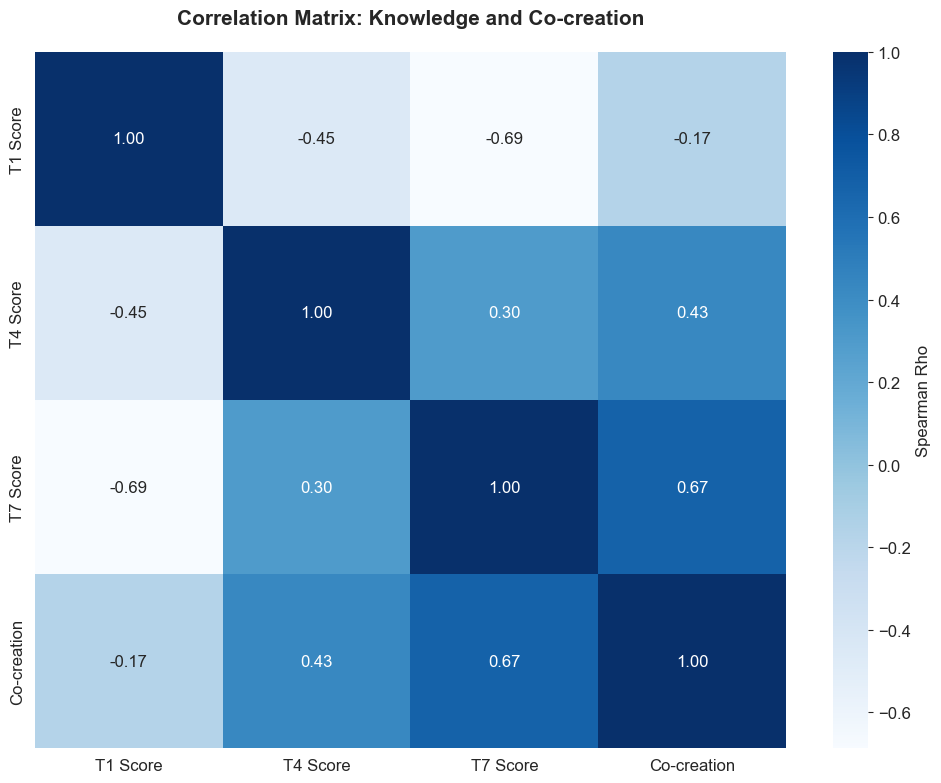

,Group,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",score_T1,score_T4,score_T7
0,2,3.0,0.000000,1.000000,2.000000
1,3,1.0,0.333333,0.666667,1.000000
2,4,1.0,0.333333,1.000000,0.333333
3,5,0.5,0.000000,1.000000,0.333333
4,6,3.0,0.333333,0.666667,1.000000
5,7,0.5,1.500000,0.500000,0.000000
6,8,0.5,0.000000,1.000000,1.000000
7,9,0.5,0.000000,0.000000,1.000000
8,10,0.0,0.666667,0.333333,0.000000


In [14]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Setup IDs and Group Mapping
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. isolate and Score Knowledge for T1, T4, and T7
def get_scores(timepoint):
    subset = df_children[df_children['Timepoint'] == timepoint].copy()
    # Correct = 1, anything else = 0
    subset[f'score_{timepoint}'] = (subset['microcontrollers_1'] == 1).astype(int) + \
                                   (subset['microcontrollers_2'] == 1).astype(int)
    return subset[['Participant ID', f'score_{timepoint}']]

df_t1_scores = get_scores('T1')
df_t4_scores = get_scores('T4')
df_t7_scores = get_scores('T7')

# 4. Merge Knowledge Timepoints (Student Level)
df_knowledge_all = df_t1_scores.merge(df_t4_scores, on='Participant ID', how='inner')\
                               .merge(df_t7_scores, on='Participant ID', how='inner')

# 5. Aggregate to Group Level (Means)
df_group_know = df_knowledge_all.merge(mapping, on='Participant ID')\
                                .groupby('Group')[['score_T1', 'score_T4', 'score_T7']].mean().reset_index()

# 6. Merge with Co-creation Level from Analysis CSV
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

# Final Dataframe for correlation
df_final_all = df_cocreat.merge(df_group_know, on='Group', how='inner')

# 7. RUN CORRELATIONS
print("--- KNOWLEDGE EVOLUTION CORRELATIONS ---")
t1_t4_rho, t1_t4_p = spearmanr(df_final_all['score_T1'], df_final_all['score_T4'])
t4_t7_rho, t4_t7_p = spearmanr(df_final_all['score_T4'], df_final_all['score_T7'])
t1_t7_rho, t1_t7_p = spearmanr(df_final_all['score_T1'], df_final_all['score_T7'])

print(f"T1 vs T4: rho = {t1_t4_rho:.2f}, p = {t1_t4_p:.3f}")
print(f"T4 vs T7: rho = {t4_t7_rho:.2f}, p = {t4_t7_p:.3f}")
print(f"T1 vs T7: rho = {t1_t7_rho:.2f}, p = {t1_t7_p:.3f}")

print("\n--- CO-CREATION CORRELATIONS ---")
t1_coc_rho, t1_coc_p = spearmanr(df_final_all['score_T1'], df_final_all[cocreation_col])
t7_coc_rho, t7_coc_p = spearmanr(df_final_all['score_T7'], df_final_all[cocreation_col])

print(f"T1 Knowledge vs. Co-creation Level: rho = {t1_coc_rho:.2f}, p = {t1_coc_p:.3f}")
print(f"T7 Knowledge vs. Co-creation Level: rho = {t7_coc_rho:.2f}, p = {t7_coc_p:.3f}")

# 8. Visualization: Heatmap of all relationships
plt.figure(figsize=(10, 8))
corr_matrix = df_final_all[['score_T1', 'score_T4', 'score_T7', cocreation_col]].corr(method='spearman')
labels = ['T1 Score', 'T4 Score', 'T7 Score', 'Co-creation']

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f",
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Spearman Rho'})

plt.title("Correlation Matrix: Knowledge and Co-creation", fontweight='bold', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

display(df_final_all)

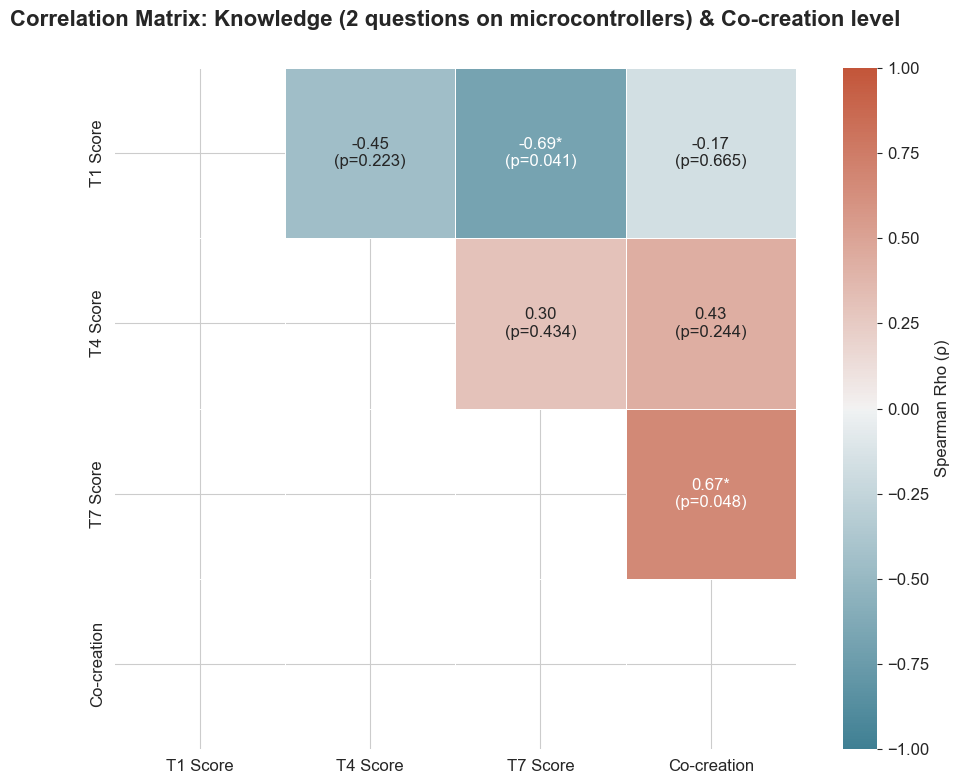

In [15]:
import numpy as np

# 1. Prepare the Correlation and P-value Matrices
cols_for_corr = ['score_T1', 'score_T4', 'score_T7', cocreation_col]
labels = ['T1 Score', 'T4 Score', 'T7 Score', 'Co-creation']

# Calculate Spearman Rho and P-values
corr_matrix = np.zeros((len(cols_for_corr), len(cols_for_corr)))
p_matrix = np.zeros((len(cols_for_corr), len(cols_for_corr)))

for i, col1 in enumerate(cols_for_corr):
    for j, col2 in enumerate(cols_for_corr):
        rho, p = spearmanr(df_final_all[col1], df_final_all[col2])
        corr_matrix[i, j] = rho
        p_matrix[i, j] = p

# 2. Create the annotations (Rho + P-value in parentheses)
annot_matrix = []
for i in range(len(cols_for_corr)):
    row = []
    for j in range(len(cols_for_corr)):
        star = "*" if p_matrix[i, j] < 0.05 else ""
        label = f"{corr_matrix[i, j]:.2f}{star}\n(p={p_matrix[i, j]:.3f})"
        row.append(label)
    annot_matrix.append(row)

# 3. Visualization: Half Matrix (FLIPPED - showing upper triangle)
plt.figure(figsize=(10, 8))

# Create a mask for the LOWER triangle (this shows the UPPER triangle)
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

# Set up color palette (Coolwarm or Blues)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=np.array(annot_matrix), 
            fmt="", 
            cmap=cmap, 
            center=0,
            vmin=-1, vmax=1,
            xticklabels=labels, 
            yticklabels=labels, 
            cbar_kws={'label': 'Spearman Rho (ρ)'},
            square=True,
            linewidths=.5)

plt.title("Correlation Matrix: Knowledge (2 questions on microcontrollers) & Co-creation level", fontweight='bold', fontsize=16, pad=30)
plt.tight_layout()
plt.show()


Data structure:
Total observations: 27
Number of groups: 9
Observations per timepoint:
Timepoint
score_T1    9
score_T4    9
score_T7    9
dtype: int64

ANALYSIS 1: Co-creation Effect on T7 Knowledge ONLY

Spearman correlation (T7 vs Co-creation): ρ = 0.671, p = 0.0477

Linear regression (T7 ~ Co-creation):
  Slope (β): 0.414
  Intercept: 0.281
  R²: 0.516
  p-value: 0.0293
  Standard error: 0.152

ANALYSIS 2: Mixed Model - Time + Co-creation (Longitudinal)


<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15552/3001993310.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_long['Time_numeric'] = df_long['Timepoint'].str.extract('(\d+)').astype(int)
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelih

          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Score   
No. Observations:  27       Method:              REML    
No. Groups:        9        Scale:               0.2410  
Min. group size:   3        Log-Likelihood:      -22.8648
Max. group size:   3        Converged:           No      
Mean group size:   3.0                                   
---------------------------------------------------------
                 Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept        0.181    0.207 0.877 0.380 -0.224  0.587
Time_numeric     0.065    0.039 1.681 0.093 -0.011  0.140
Cocreation_Level 0.137    0.090 1.517 0.129 -0.040  0.313
Group Var        0.000                                   


ANALYSIS 3: Mixed Model - Time × Co-creation Interaction
                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       Score   
No. Observa

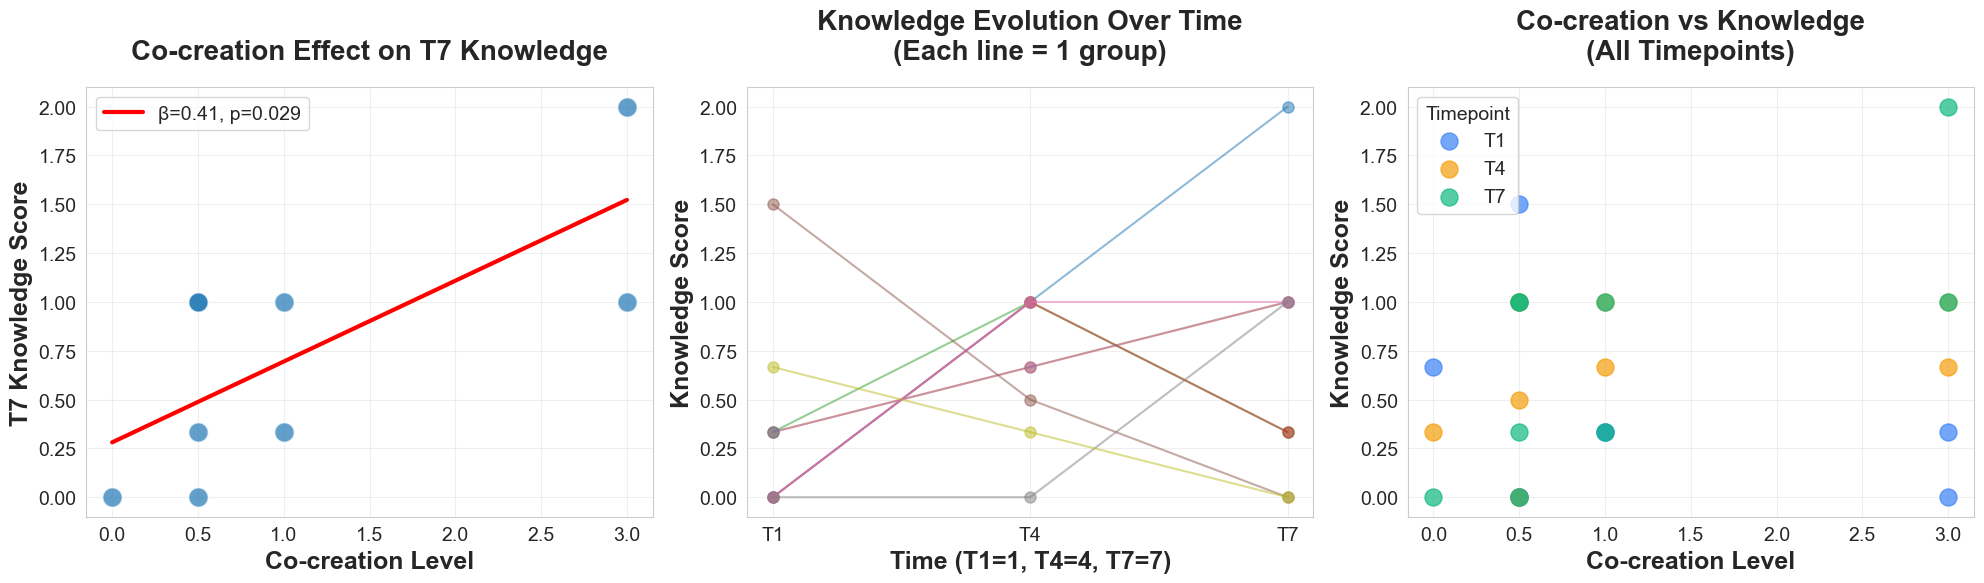


SUMMARY OF KEY FINDINGS
                                      Analysis Coefficient p-value                                      Interpretation
                   T7 only: Co-creation effect       0.414  0.0293        Effect of co-creation on post-test (T7) only
       Mixed Model: Time effect (longitudinal)       0.065  0.0929 Effect of time on knowledge (across all timepoints)
Mixed Model: Co-creation effect (longitudinal)       0.137  0.1293       Effect of co-creation (across all timepoints)
   Mixed Model: Time × Co-creation interaction       0.088  0.0077             Does co-creation effect differ by time?


In [16]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import numpy as np

# 1. Reshape data to long format for mixed model
df_long = df_final_all.melt(
    id_vars=['Group', cocreation_col],
    value_vars=['score_T1', 'score_T4', 'score_T7'],
    var_name='Timepoint',
    value_name='Score'
)

# Extract numeric timepoint (1, 4, 7)
df_long['Time_numeric'] = df_long['Timepoint'].str.extract('(\d+)').astype(int)

# Rename co-creation column for easier formula writing
df_long = df_long.rename(columns={cocreation_col: 'Cocreation_Level'})

print("Data structure:")
print(f"Total observations: {len(df_long)}")
print(f"Number of groups: {df_long['Group'].nunique()}")
print(f"Observations per timepoint:")
print(df_long.groupby('Timepoint').size())

# 2. SEPARATE ANALYSIS FOR T7 ONLY
print("\n" + "="*60)
print("ANALYSIS 1: Co-creation Effect on T7 Knowledge ONLY")
print("="*60)

df_t7_only = df_final_all[['Group', cocreation_col, 'score_T7']].copy()
df_t7_only = df_t7_only.rename(columns={cocreation_col: 'Cocreation_Level', 'score_T7': 'Score'})

# Since we only have one observation per group, we can use simple regression
# But let's also show the correlation
from scipy.stats import spearmanr
rho_t7, p_t7 = spearmanr(df_t7_only['Cocreation_Level'], df_t7_only['Score'])
print(f"\nSpearman correlation (T7 vs Co-creation): ρ = {rho_t7:.3f}, p = {p_t7:.4f}")

# Linear regression for T7
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_t7_only['Cocreation_Level'], df_t7_only['Score'])
print(f"\nLinear regression (T7 ~ Co-creation):")
print(f"  Slope (β): {slope:.3f}")
print(f"  Intercept: {intercept:.3f}")
print(f"  R²: {r_value**2:.3f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Standard error: {std_err:.3f}")

# 3. MIXED MODEL FOR LONGITUDINAL DATA (all timepoints)
print("\n" + "="*60)
print("ANALYSIS 2: Mixed Model - Time + Co-creation (Longitudinal)")
print("="*60)

md_full = mixedlm("Score ~ Time_numeric + Cocreation_Level", df_long, groups=df_long["Group"])
mdf_full = md_full.fit()
print(mdf_full.summary())

# 4. MIXED MODEL WITH INTERACTION
print("\n" + "="*60)
print("ANALYSIS 3: Mixed Model - Time × Co-creation Interaction")
print("="*60)

md_interact = mixedlm("Score ~ Time_numeric * Cocreation_Level", df_long, groups=df_long["Group"])
mdf_interact = md_interact.fit()
print(mdf_interact.summary())

# 5. VISUALIZATION - IMPROVED
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: T7 Co-creation effect ONLY
ax1 = axes[0]
sns.scatterplot(data=df_t7_only, x='Cocreation_Level', y='Score', s=200, alpha=0.7, ax=ax1)
# Add regression line
x_range = np.linspace(df_t7_only['Cocreation_Level'].min(), df_t7_only['Cocreation_Level'].max(), 100)
y_pred = slope * x_range + intercept
ax1.plot(x_range, y_pred, 'r-', linewidth=3, label=f'β={slope:.2f}, p={p_value:.3f}')
ax1.set_xlabel('Co-creation Level', fontsize=18, fontweight='bold')
ax1.set_ylabel('T7 Knowledge Score', fontsize=18, fontweight='bold')
ax1.set_title('Co-creation Effect on T7 Knowledge', fontsize=20, fontweight='bold', pad=20)
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Knowledge evolution over time (by group)
ax2 = axes[1]
for group in df_long['Group'].unique():
    group_data = df_long[df_long['Group'] == group]
    ax2.plot(group_data['Time_numeric'], group_data['Score'], 
             marker='o', alpha=0.5, linewidth=1.5, markersize=8)
ax2.set_xlabel('Time (T1=1, T4=4, T7=7)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Knowledge Score', fontsize=18, fontweight='bold')
ax2.set_title('Knowledge Evolution Over Time\n(Each line = 1 group)', fontsize=20, fontweight='bold', pad=20)
ax2.tick_params(labelsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([1, 4, 7])
ax2.set_xticklabels(['T1', 'T4', 'T7'])

# Plot 3: Co-creation vs Score colored by timepoint
ax3 = axes[2]
for tp, color in zip(['T1', 'T4', 'T7'], ['#3b82f6', '#f59e0b', '#10b981']):
    tp_data = df_long[df_long['Timepoint'] == f'score_{tp}']
    ax3.scatter(tp_data['Cocreation_Level'], tp_data['Score'], 
                s=150, alpha=0.7, label=tp, color=color)
ax3.set_xlabel('Co-creation Level', fontsize=18, fontweight='bold')
ax3.set_ylabel('Knowledge Score', fontsize=18, fontweight='bold')
ax3.set_title('Co-creation vs Knowledge\n(All Timepoints)', fontsize=20, fontweight='bold', pad=20)
ax3.tick_params(labelsize=14)
ax3.legend(fontsize=14, title='Timepoint', title_fontsize=14)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Summary table
print("\n" + "="*60)
print("SUMMARY OF KEY FINDINGS")
print("="*60)

summary_data = {
    'Analysis': [
        'T7 only: Co-creation effect',
        'Mixed Model: Time effect (longitudinal)',
        'Mixed Model: Co-creation effect (longitudinal)',
        'Mixed Model: Time × Co-creation interaction'
    ],
    'Coefficient': [
        f'{slope:.3f}',
        f'{mdf_full.params["Time_numeric"]:.3f}',
        f'{mdf_full.params["Cocreation_Level"]:.3f}',
        f'{mdf_interact.params["Time_numeric:Cocreation_Level"]:.3f}'
    ],
    'p-value': [
        f'{p_value:.4f}',
        f'{mdf_full.pvalues["Time_numeric"]:.4f}',
        f'{mdf_full.pvalues["Cocreation_Level"]:.4f}',
        f'{mdf_interact.pvalues["Time_numeric:Cocreation_Level"]:.4f}'
    ],
    'Interpretation': [
        'Effect of co-creation on post-test (T7) only',
        'Effect of time on knowledge (across all timepoints)',
        'Effect of co-creation (across all timepoints)',
        'Does co-creation effect differ by time?'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

ANALYSIS: Does T1 Knowledge Predict Co-creation Level?

Sample size: 9 groups

Descriptive Statistics:
       score_T1  Cocreation_Level
count  9.000000          9.000000
mean   0.351852          1.111111
std    0.489078          1.111805
min    0.000000          0.000000
25%    0.000000          0.500000
50%    0.333333          0.500000
75%    0.333333          1.000000
max    1.500000          3.000000

------------------------------------------------------------
1. CORRELATION: T1 Score vs. Co-creation Level
------------------------------------------------------------

Spearman's ρ = -0.168
p-value = 0.6653
✗ No significant correlation (p = 0.6653)

------------------------------------------------------------
2. LINEAR REGRESSION: Co-creation ~ T1 Score
------------------------------------------------------------

Regression equation: Co-creation = 1.314 + -0.576 × T1_Score
Slope (β): -0.576
Intercept: 1.314
R² = 0.064 (6.4% variance explained)
p-value = 0.5108
Standard error: 0.83

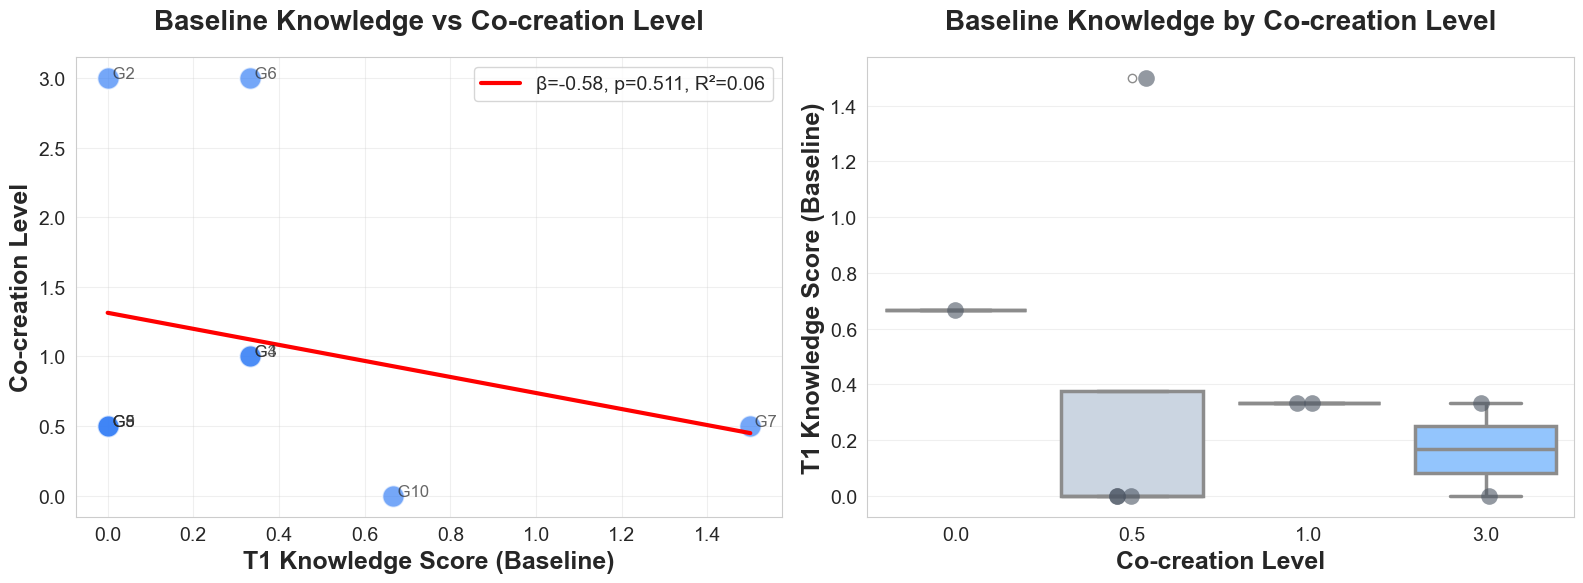


COMPARISON: T1 vs T7 Predicting Co-creation

            Predictor Spearman ρ p-value                              Interpretation
 T1 Score (Baseline)     -0.168  0.6653 Does initial knowledge predict co-creation?
T7 Score (Post-test)      0.671  0.0477   Does co-creation predict final knowledge?

INTERPRETATION

→ LEARNING EFFECT:
  - Co-creation predicts T7 (but T1 doesn't predict co-creation)
  - Co-creation level appears to causally influence learning outcomes

DATA TABLE
 Group  T1 Score  Co-creation  T7 Score
     2  0.000000          3.0  2.000000
     3  0.333333          1.0  1.000000
     4  0.333333          1.0  0.333333
     5  0.000000          0.5  0.333333
     6  0.333333          3.0  1.000000
     7  1.500000          0.5  0.000000
     8  0.000000          0.5  1.000000
     9  0.000000          0.5  1.000000
    10  0.666667          0.0  0.000000


In [17]:
import statsmodels.api as sm
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("ANALYSIS: Does T1 Knowledge Predict Co-creation Level?")
print("="*60)

# Prepare data
df_t1_cocreation = df_final_all[['Group', 'score_T1', cocreation_col]].copy()
df_t1_cocreation = df_t1_cocreation.rename(columns={cocreation_col: 'Cocreation_Level'})

print(f"\nSample size: {len(df_t1_cocreation)} groups")
print("\nDescriptive Statistics:")
print(df_t1_cocreation[['score_T1', 'Cocreation_Level']].describe())

# 1. CORRELATION ANALYSIS
print("\n" + "-"*60)
print("1. CORRELATION: T1 Score vs. Co-creation Level")
print("-"*60)

rho, p_val = spearmanr(df_t1_cocreation['score_T1'], df_t1_cocreation['Cocreation_Level'])
print(f"\nSpearman's ρ = {rho:.3f}")
print(f"p-value = {p_val:.4f}")

if p_val < 0.05:
    print(f"✓ Significant correlation (p < 0.05)")
    if rho > 0:
        print("  → Groups with higher T1 knowledge tend to have higher co-creation levels")
    else:
        print("  → Groups with higher T1 knowledge tend to have lower co-creation levels")
else:
    print(f"✗ No significant correlation (p = {p_val:.4f})")

# 2. LINEAR REGRESSION
print("\n" + "-"*60)
print("2. LINEAR REGRESSION: Co-creation ~ T1 Score")
print("-"*60)

slope, intercept, r_value, p_value, std_err = linregress(df_t1_cocreation['score_T1'], 
                                                          df_t1_cocreation['Cocreation_Level'])

print(f"\nRegression equation: Co-creation = {intercept:.3f} + {slope:.3f} × T1_Score")
print(f"Slope (β): {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R² = {r_value**2:.3f} ({r_value**2*100:.1f}% variance explained)")
print(f"p-value = {p_value:.4f}")
print(f"Standard error: {std_err:.3f}")

# 3. VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter with regression line
ax1 = axes[0]
sns.scatterplot(data=df_t1_cocreation, x='score_T1', y='Cocreation_Level', 
                s=250, alpha=0.7, ax=ax1, color='#3b82f6')

# Add regression line
x_range = np.linspace(df_t1_cocreation['score_T1'].min(), 
                     df_t1_cocreation['score_T1'].max(), 100)
y_pred = slope * x_range + intercept
ax1.plot(x_range, y_pred, 'r-', linewidth=3, 
         label=f'β={slope:.2f}, p={p_value:.3f}, R²={r_value**2:.2f}')

# Add group labels
for idx, row in df_t1_cocreation.iterrows():
    ax1.text(row['score_T1'], row['Cocreation_Level'], 
             f" G{int(row['Group'])}", fontsize=12, alpha=0.7)

ax1.set_xlabel('T1 Knowledge Score (Baseline)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Co-creation Level', fontsize=18, fontweight='bold')
ax1.set_title('Baseline Knowledge vs Co-creation Level', 
              fontsize=20, fontweight='bold', pad=20)
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=14, loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Box plot by co-creation level
ax2 = axes[1]
cocreation_levels = sorted(df_t1_cocreation['Cocreation_Level'].unique())
colors = ['#E2E8F0', '#CBD5E1', '#A5D8D0', '#93C5FD']

sns.boxplot(data=df_t1_cocreation, x='Cocreation_Level', y='score_T1', 
            color='#E2E8F0', ax=ax2, linewidth=2.5)

# Color boxes
for i, patch in enumerate(ax2.patches):
    if i < len(colors):
        patch.set_facecolor(colors[i])

sns.stripplot(data=df_t1_cocreation, x='Cocreation_Level', y='score_T1', 
              color='#4B5563', alpha=0.6, size=12, ax=ax2)

ax2.set_xlabel('Co-creation Level', fontsize=18, fontweight='bold')
ax2.set_ylabel('T1 Knowledge Score (Baseline)', fontsize=18, fontweight='bold')
ax2.set_title('Baseline Knowledge by Co-creation Level', 
              fontsize=20, fontweight='bold', pad=20)
ax2.tick_params(labelsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. COMPARE WITH T7 EFFECT
print("\n" + "="*60)
print("COMPARISON: T1 vs T7 Predicting Co-creation")
print("="*60)

df_t7_cocreation = df_final_all[['Group', 'score_T7', cocreation_col]].copy()
rho_t7, p_t7 = spearmanr(df_t7_cocreation['score_T7'], df_t7_cocreation[cocreation_col])

comparison = pd.DataFrame({
    'Predictor': ['T1 Score (Baseline)', 'T7 Score (Post-test)'],
    'Spearman ρ': [f'{rho:.3f}', f'{rho_t7:.3f}'],
    'p-value': [f'{p_val:.4f}', f'{p_t7:.4f}'],
    'Interpretation': [
        'Does initial knowledge predict co-creation?',
        'Does co-creation predict final knowledge?'
    ]
})

print("\n", comparison.to_string(index=False))

# 5. INTERPRETATION
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

if p_val < 0.05 and p_t7 < 0.05:
    print("\n⚠️  BIDIRECTIONAL RELATIONSHIP:")
    print("  - T1 predicts co-creation (baseline knowledge influences engagement)")
    print("  - Co-creation predicts T7 (engagement influences learning)")
    print("  → This suggests a complex interplay between prior knowledge and learning")
elif p_val < 0.05:
    print("\n→ SELECTION EFFECT:")
    print("  - T1 predicts co-creation level")
    print("  - Groups with different baseline knowledge engaged differently")
    print("  → The co-creation level may reflect initial group characteristics")
elif p_t7 < 0.05:
    print("\n→ LEARNING EFFECT:")
    print("  - Co-creation predicts T7 (but T1 doesn't predict co-creation)")
    print("  - Co-creation level appears to causally influence learning outcomes")
else:
    print("\n→ NO CLEAR RELATIONSHIP:")
    print("  - Neither T1 nor co-creation show strong relationships")
    print("  - May need larger sample size or different measures")

# Display data table
print("\n" + "="*60)
print("DATA TABLE")
print("="*60)
display_df = df_t1_cocreation.copy()
display_df['score_T7'] = df_final_all['score_T7'].values
display_df = display_df[['Group', 'score_T1', 'Cocreation_Level', 'score_T7']]
display_df.columns = ['Group', 'T1 Score', 'Co-creation', 'T7 Score']
print(display_df.to_string(index=False))

Updated Group-level Knowledge Scores (with all T7 students):
 Group  score_T1  score_T4  score_T7  Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)
     2  0.666667  1.000000  1.500000                                                                                                                                                      3.0
     3  0.333333  0.666667  1.000000                                                                                                                                                      1.0
     4  0.333333  1.000000  0.333333                                                                                                                                                      1.0
     5  0.000000  1.000000  0.333333                                                                                                                                               

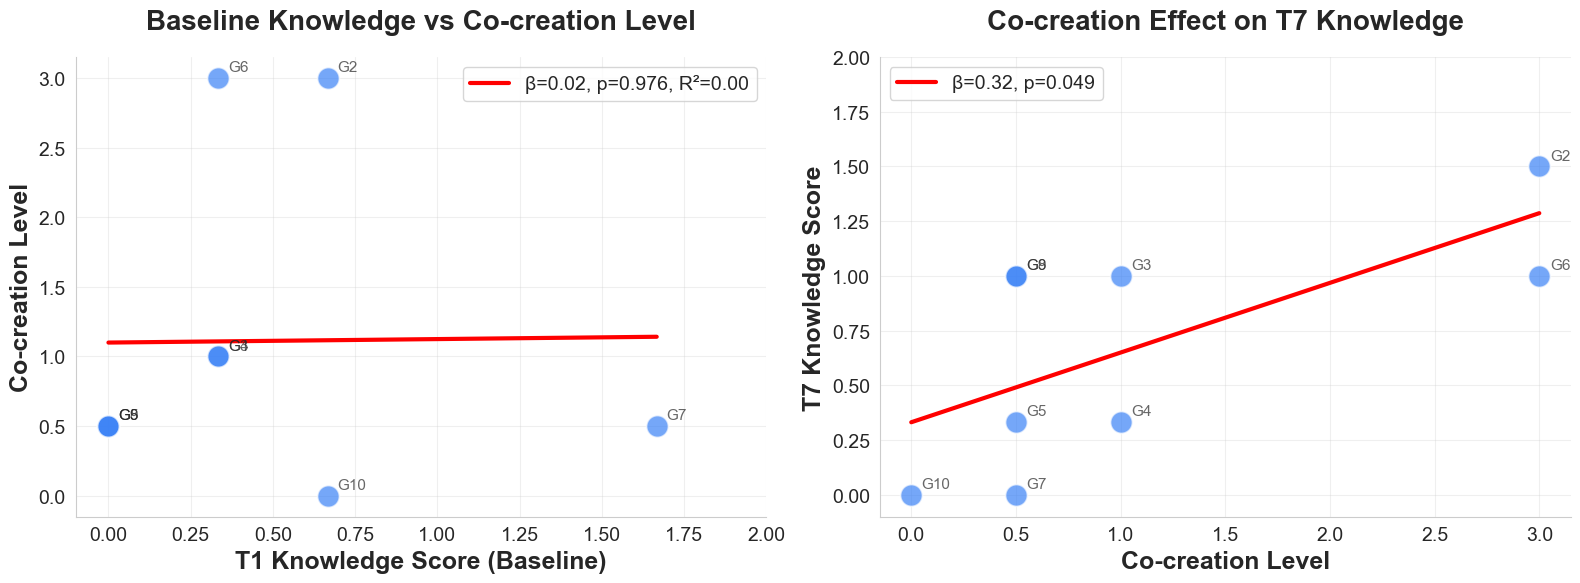


SUMMARY: Baseline Knowledge vs Co-creation vs Learning

1. T1 Knowledge → Co-creation Level:
   Spearman ρ = 0.114, p = 0.976
   β = 0.02, R² = 0.00

2. Co-creation Level → T7 Knowledge:
   Spearman ρ = 0.671, p = 0.049
   β = 0.32, R² = 0.45


In [18]:
import pandas as pd
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# FIXED VERSION: Rebuild df_final_all with outer joins to keep all T7 students

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Setup IDs and Group Mapping
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. Score Knowledge for T1, T4, and T7
def get_scores(timepoint):
    subset = df_children[df_children['Timepoint'] == timepoint].copy()
    # Correct = 1, anything else = 0
    subset[f'score_{timepoint}'] = (subset['microcontrollers_1'] == 1).astype(int) + \
                                   (subset['microcontrollers_2'] == 1).astype(int)
    return subset[['Participant ID', f'score_{timepoint}']]

df_t1_scores = get_scores('T1')
df_t4_scores = get_scores('T4')
df_t7_scores = get_scores('T7')

# 4. FIXED: Use OUTER join to keep all students even if missing some timepoints
df_knowledge_all = df_t1_scores.merge(df_t4_scores, on='Participant ID', how='outer')\
                               .merge(df_t7_scores, on='Participant ID', how='outer')

# 5. Merge with mapping and aggregate to group level (means)
df_group_know = df_knowledge_all.merge(mapping, on='Participant ID', how='left')\
                                .groupby('Group')[['score_T1', 'score_T4', 'score_T7']].mean().reset_index()

# 6. Merge with Co-creation Level from Analysis CSV
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

# Final Dataframe for correlation (UPDATED)
df_final_all = df_cocreat.merge(df_group_know, on='Group', how='inner')

print("Updated Group-level Knowledge Scores (with all T7 students):")
print(df_final_all[['Group', 'score_T1', 'score_T4', 'score_T7', cocreation_col]].to_string(index=False))

# Verification
print("\n" + "="*60)
print("VERIFICATION: Group 2 T7 Score")
print("="*60)
group2_score = df_final_all[df_final_all['Group'] == 2]['score_T7'].values[0]
print(f"Group 2 T7 score: {group2_score:.2f} (Expected: 1.50)")
if abs(group2_score - 1.5) < 0.01:
    print("✓ FIXED!")

# ===== NOW CREATE THE TWO PLOTS =====

# Prepare data for both analyses
df_t1_cocreation = df_final_all[['Group', 'score_T1', cocreation_col]].copy()
df_t1_cocreation = df_t1_cocreation.rename(columns={cocreation_col: 'Cocreation_Level'})

df_t7_cocreation = df_final_all[['Group', 'score_T7', cocreation_col]].copy()
df_t7_cocreation = df_t7_cocreation.rename(columns={cocreation_col: 'Cocreation_Level'})

# Run regressions
slope_t1, intercept_t1, r_t1, p_t1, se_t1 = linregress(df_t1_cocreation['score_T1'], 
                                                        df_t1_cocreation['Cocreation_Level'])
slope_t7, intercept_t7, r_t7, p_t7, se_t7 = linregress(df_t7_cocreation['Cocreation_Level'],
                                                        df_t7_cocreation['score_T7'])

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== PLOT 1: T1 Knowledge → Co-creation Level =====
ax1 = axes[0]

# Scatter plot
sns.scatterplot(data=df_t1_cocreation, x='score_T1', y='Cocreation_Level', 
                s=250, alpha=0.7, ax=ax1, color='#3b82f6')

# Regression line
x_range_t1 = np.linspace(df_t1_cocreation['score_T1'].min(), 
                         df_t1_cocreation['score_T1'].max(), 100)
y_pred_t1 = slope_t1 * x_range_t1 + intercept_t1
ax1.plot(x_range_t1, y_pred_t1, 'r-', linewidth=3, 
         label=f'β={slope_t1:.2f}, p={p_t1:.3f}, R²={r_t1**2:.2f}')

# Add group labels
for idx, row in df_t1_cocreation.iterrows():
    ax1.text(row['score_T1'] + 0.03, row['Cocreation_Level'] + 0.05, 
             f"G{int(row['Group'])}", fontsize=11, alpha=0.7)

ax1.set_xlabel('T1 Knowledge Score (Baseline)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Co-creation Level', fontsize=18, fontweight='bold')
ax1.set_title('Baseline Knowledge vs Co-creation Level', 
              fontsize=20, fontweight='bold', pad=20)
ax1.set_xlim(-0.1, 2.0)  # Set x-axis to 0-2
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=14, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ===== PLOT 2: Co-creation Level → T7 Knowledge =====
ax2 = axes[1]

# Scatter plot
sns.scatterplot(data=df_t7_cocreation, x='Cocreation_Level', y='score_T7', 
                s=250, alpha=0.7, ax=ax2, color='#3b82f6')

# Regression line
x_range_t7 = np.linspace(df_t7_cocreation['Cocreation_Level'].min(), 
                         df_t7_cocreation['Cocreation_Level'].max(), 100)
y_pred_t7 = slope_t7 * x_range_t7 + intercept_t7
ax2.plot(x_range_t7, y_pred_t7, 'r-', linewidth=3, 
         label=f'β={slope_t7:.2f}, p={p_t7:.3f}')

# Add group labels
for idx, row in df_t7_cocreation.iterrows():
    ax2.text(row['Cocreation_Level'] + 0.05, row['score_T7'] + 0.03, 
             f"G{int(row['Group'])}", fontsize=11, alpha=0.7)

ax2.set_xlabel('Co-creation Level', fontsize=18, fontweight='bold')
ax2.set_ylabel('T7 Knowledge Score', fontsize=18, fontweight='bold')
ax2.set_title('Co-creation Effect on T7 Knowledge', 
              fontsize=20, fontweight='bold', pad=20)
ax2.set_ylim(-0.1, 2.0)  # Set y-axis to 0-2
ax2.tick_params(labelsize=14)
ax2.legend(fontsize=14, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: Baseline Knowledge vs Co-creation vs Learning")
print("="*60)
print(f"\n1. T1 Knowledge → Co-creation Level:")
print(f"   Spearman ρ = {spearmanr(df_t1_cocreation['score_T1'], df_t1_cocreation['Cocreation_Level'], nan_policy='omit')[0]:.3f}, p = {p_t1:.3f}")
print(f"   β = {slope_t1:.2f}, R² = {r_t1**2:.2f}")

print(f"\n2. Co-creation Level → T7 Knowledge:")
print(f"   Spearman ρ = {spearmanr(df_t7_cocreation['Cocreation_Level'], df_t7_cocreation['score_T7'], nan_policy='omit')[0]:.3f}, p = {p_t7:.3f}")
print(f"   β = {slope_t7:.2f}, R² = {r_t7**2:.2f}")

In [19]:
import pandas as pd
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("DATA VERIFICATION: Group-level Knowledge Scores")
print("="*60)

# Let's check the raw individual-level data first
print("\n1. INDIVIDUAL-LEVEL SCORES (T7 example):")
print("-"*60)
df_t7_individual = df_children[df_children['Timepoint'] == 'T7'].copy()
df_t7_individual['score_T7'] = (df_t7_individual['microcontrollers_1'] == 1).astype(int) + \
                                 (df_t7_individual['microcontrollers_2'] == 1).astype(int)

# Merge with group info
df_t7_individual = df_t7_individual.merge(mapping[['Participant ID', 'Group']], on='Participant ID')
df_t7_individual = df_t7_individual[['Participant ID', 'Group', 'microcontrollers_1', 'microcontrollers_2', 'score_T7']].sort_values('Group')

print(df_t7_individual.to_string(index=False))

# Check Group 2 specifically
print("\n2. GROUP 2 DETAIL (T7):")
print("-"*60)
group2_t7 = df_t7_individual[df_t7_individual['Group'] == 2]
print(group2_t7.to_string(index=False))
print(f"\nGroup 2 T7 Average: {group2_t7['score_T7'].mean():.2f}")
print(f"Group 2 T7 Count: {len(group2_t7)} students")

# Now check what's in df_final_all
print("\n3. GROUP-LEVEL AGGREGATED SCORES (from df_final_all):")
print("-"*60)
print(df_final_all[['Group', 'score_T1', 'score_T4', 'score_T7', cocreation_col]].to_string(index=False))

# Verify the aggregation step
print("\n4. VERIFY AGGREGATION PROCESS:")
print("-"*60)
df_knowledge_all_check = df_t1_scores.merge(df_t4_scores, on='Participant ID', how='inner')\
                                      .merge(df_t7_scores, on='Participant ID', how='inner')

print("Individual level knowledge (first 10 rows):")
print(df_knowledge_all_check.head(10).to_string(index=False))

# Merge with mapping and aggregate
df_group_know_check = df_knowledge_all_check.merge(mapping, on='Participant ID')\
                                            .groupby('Group')[['score_T1', 'score_T4', 'score_T7']].agg(['mean', 'count']).reset_index()
print("\nGroup-level aggregated:")
print(df_group_know_check.to_string(index=False))

print("\n" + "="*60)
print("ISSUE DIAGNOSIS")
print("="*60)
if df_final_all[df_final_all['Group'] == 2]['score_T7'].values[0] != group2_t7['score_T7'].mean():
    print("⚠️  WARNING: Mismatch detected!")
    print(f"   Expected Group 2 T7 score: {group2_t7['score_T7'].mean():.2f}")
    print(f"   Actual in df_final_all: {df_final_all[df_final_all['Group'] == 2]['score_T7'].values[0]:.2f}")
    print("\n   Possible causes:")
    print("   - Missing students in the merge (inner join drops unmatched)")
    print("   - Duplicate entries")
    print("   - Incorrect aggregation function")
else:
    print("✓ Aggregation is correct")

DATA VERIFICATION: Group-level Knowledge Scores

1. INDIVIDUAL-LEVEL SCORES (T7 example):
------------------------------------------------------------
 Participant ID  Group  microcontrollers_1  microcontrollers_2  score_T7
              1    1.0                 1.0                 0.0         1
              2    1.0                 1.0                 0.0         1
              8    1.0                 1.0                99.0         1
              3    2.0                 1.0                 1.0         2
             10    2.0                 1.0                 0.0         1
              4    3.0                 0.0                 1.0         1
              6    3.0                99.0                 0.0         0
             13    3.0                 1.0                 1.0         2
              5    4.0                 0.0                 0.0         0
              7    4.0                 1.0                 0.0         1
             12    4.0                99.0    

Updated Group-level Knowledge Scores (with all T7 students):
 Group  score_T1  score_T4  score_T7
   1.0  0.500000  0.250000  1.000000
   2.0  0.666667  1.000000  1.500000
   3.0  0.333333  0.666667  1.000000
   4.0  0.333333  1.000000  0.333333
   5.0  0.000000  1.000000  0.333333
   6.0  0.333333  0.666667  1.000000
   7.0  1.666667  0.666667  0.000000
   8.0  0.000000  1.333333  1.000000
   9.0  0.000000  0.000000  1.000000
  10.0  0.666667  0.333333  0.000000

VERIFICATION: Group 2 T7 Score
Group 2 T7 score in df_final_all: 1.50
Expected (average of 2 and 1): 1.50
✓ FIXED!

KNOWLEDGE EVOLUTION CORRELATIONS
T1 vs T4: rho = -0.22, p = 0.562
T4 vs T7: rho = 0.24, p = 0.540
T1 vs T7: rho = -0.32, p = 0.409

CO-CREATION CORRELATIONS
T1 Knowledge vs. Co-creation Level: rho = 0.11, p = 0.770
T7 Knowledge vs. Co-creation Level: rho = 0.67, p = 0.048


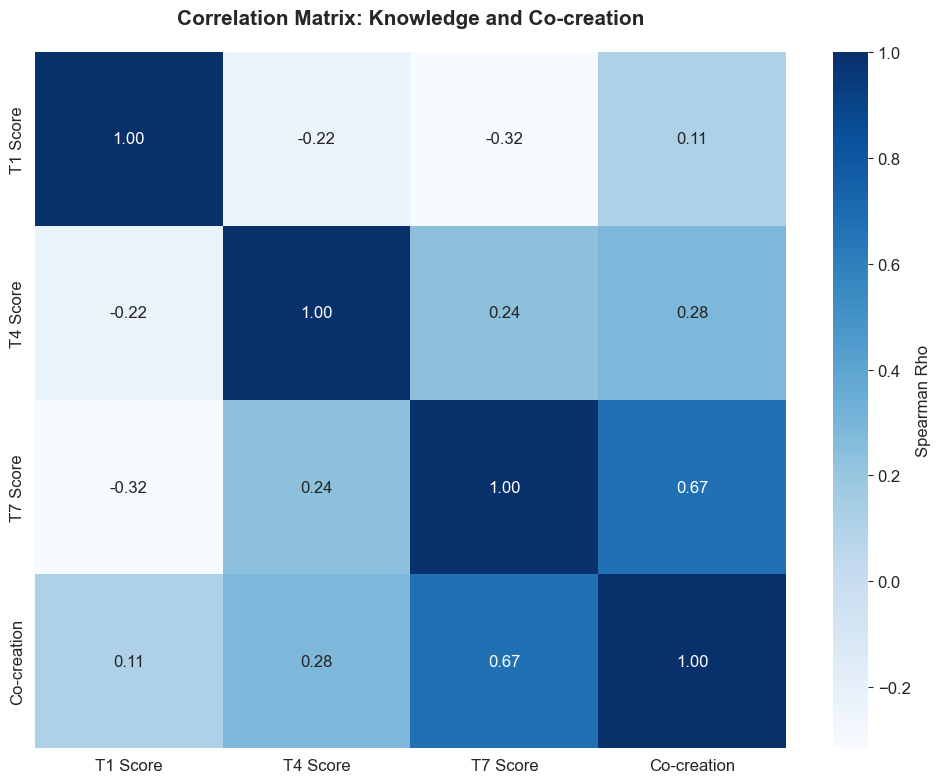


FINAL DATA TABLE


,Group,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",score_T1,score_T4,score_T7
0,2,3.0,0.666667,1.000000,1.500000
1,3,1.0,0.333333,0.666667,1.000000
2,4,1.0,0.333333,1.000000,0.333333
3,5,0.5,0.000000,1.000000,0.333333
4,6,3.0,0.333333,0.666667,1.000000
5,7,0.5,1.666667,0.666667,0.000000
6,8,0.5,0.000000,1.333333,1.000000
7,9,0.5,0.000000,0.000000,1.000000
8,10,0.0,0.666667,0.333333,0.000000


In [20]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Setup IDs and Group Mapping
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. Score Knowledge for T1, T4, and T7
def get_scores(timepoint):
    subset = df_children[df_children['Timepoint'] == timepoint].copy()
    # Correct = 1, anything else = 0
    subset[f'score_{timepoint}'] = (subset['microcontrollers_1'] == 1).astype(int) + \
                                   (subset['microcontrollers_2'] == 1).astype(int)
    return subset[['Participant ID', f'score_{timepoint}']]

df_t1_scores = get_scores('T1')
df_t4_scores = get_scores('T4')
df_t7_scores = get_scores('T7')

# 4. FIXED: Use OUTER join to keep all students even if missing some timepoints
df_knowledge_all = df_t1_scores.merge(df_t4_scores, on='Participant ID', how='outer')\
                               .merge(df_t7_scores, on='Participant ID', how='outer')

# 5. Merge with mapping and aggregate to group level (means)
df_group_know = df_knowledge_all.merge(mapping, on='Participant ID', how='left')\
                                .groupby('Group')[['score_T1', 'score_T4', 'score_T7']].mean().reset_index()

print("Updated Group-level Knowledge Scores (with all T7 students):")
print(df_group_know.to_string(index=False))

# 6. Merge with Co-creation Level from Analysis CSV
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

# Final Dataframe for correlation
df_final_all = df_cocreat.merge(df_group_know, on='Group', how='inner')

print("\n" + "="*60)
print("VERIFICATION: Group 2 T7 Score")
print("="*60)
group2_score = df_final_all[df_final_all['Group'] == 2]['score_T7'].values[0]
print(f"Group 2 T7 score in df_final_all: {group2_score:.2f}")
print(f"Expected (average of 2 and 1): 1.50")
if abs(group2_score - 1.5) < 0.01:
    print("✓ FIXED!")
else:
    print("⚠️  Still incorrect")

# 7. RUN CORRELATIONS
print("\n" + "="*60)
print("KNOWLEDGE EVOLUTION CORRELATIONS")
print("="*60)
t1_t4_rho, t1_t4_p = spearmanr(df_final_all['score_T1'], df_final_all['score_T4'], nan_policy='omit')
t4_t7_rho, t4_t7_p = spearmanr(df_final_all['score_T4'], df_final_all['score_T7'], nan_policy='omit')
t1_t7_rho, t1_t7_p = spearmanr(df_final_all['score_T1'], df_final_all['score_T7'], nan_policy='omit')

print(f"T1 vs T4: rho = {t1_t4_rho:.2f}, p = {t1_t4_p:.3f}")
print(f"T4 vs T7: rho = {t4_t7_rho:.2f}, p = {t4_t7_p:.3f}")
print(f"T1 vs T7: rho = {t1_t7_rho:.2f}, p = {t1_t7_p:.3f}")

print("\n" + "="*60)
print("CO-CREATION CORRELATIONS")
print("="*60)
t1_coc_rho, t1_coc_p = spearmanr(df_final_all['score_T1'], df_final_all[cocreation_col], nan_policy='omit')
t7_coc_rho, t7_coc_p = spearmanr(df_final_all['score_T7'], df_final_all[cocreation_col], nan_policy='omit')

print(f"T1 Knowledge vs. Co-creation Level: rho = {t1_coc_rho:.2f}, p = {t1_coc_p:.3f}")
print(f"T7 Knowledge vs. Co-creation Level: rho = {t7_coc_rho:.2f}, p = {t7_coc_p:.3f}")

# 8. Visualization: Heatmap of all relationships
plt.figure(figsize=(10, 8))
corr_matrix = df_final_all[['score_T1', 'score_T4', 'score_T7', cocreation_col]].corr(method='spearman')
labels = ['T1 Score', 'T4 Score', 'T7 Score', 'Co-creation']

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f",
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Spearman Rho'})

plt.title("Correlation Matrix: Knowledge and Co-creation", fontweight='bold', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL DATA TABLE")
print("="*60)
display(df_final_all)

In [21]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import pandas as pd
import numpy as np

print("="*60)
print("MIXED MODELS WITH RANDOM EFFECTS")
print("="*60)

# 1. Reshape to long format for mixed modeling
df_long = df_final_all.melt(
    id_vars=['Group', cocreation_col],
    value_vars=['score_T1', 'score_T4', 'score_T7'],
    var_name='Timepoint',
    value_name='Score'
)

# Extract numeric timepoint (1, 4, 7)
df_long['Time_numeric'] = df_long['Timepoint'].str.extract('(\d+)').astype(int)
df_long = df_long.rename(columns={cocreation_col: 'Cocreation_Level'})

print("\nData structure for mixed models:")
print(df_long.head(15).to_string(index=False))
print(f"\nTotal observations: {len(df_long)}")
print(f"Number of groups: {df_long['Group'].nunique()}")

# 2. MIXED MODEL 1: Co-creation effect on T7 only
print("\n" + "="*60)
print("MODEL 1: T7 Only - Does Co-creation Predict T7 Knowledge?")
print("="*60)
print("Note: Since only one observation per group at T7, this is equivalent to simple regression")
print("Random effects cannot be estimated with single observation per group.")

df_t7_only = df_long[df_long['Timepoint'] == 'score_T7'].dropna()
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_t7_only['Cocreation_Level'], df_t7_only['Score'])
print(f"\nSimple regression: β = {slope:.3f}, p = {p_value:.4f}, R² = {r_value**2:.3f}")

# 3. MIXED MODEL 2: Longitudinal - Co-creation effect across all timepoints
print("\n" + "="*60)
print("MODEL 2: Longitudinal Mixed Model (Random Intercepts)")
print("="*60)
print("Model: Score ~ Time + Co-creation + (1|Group)")
print("Random effect: Group (accounts for clustering within groups)")

try:
    md_longitudinal = mixedlm("Score ~ Time_numeric + Cocreation_Level", 
                              df_long, 
                              groups=df_long["Group"])
    mdf_longitudinal = md_longitudinal.fit()
    print(mdf_longitudinal.summary())
    
    print("\n" + "-"*60)
    print("KEY RESULTS:")
    print("-"*60)
    print(f"Time effect: β = {mdf_longitudinal.params['Time_numeric']:.3f}, p = {mdf_longitudinal.pvalues['Time_numeric']:.4f}")
    print(f"Co-creation effect: β = {mdf_longitudinal.params['Cocreation_Level']:.3f}, p = {mdf_longitudinal.pvalues['Cocreation_Level']:.4f}")
    print(f"\nRandom effects variance (Group): {mdf_longitudinal.cov_re.values[0][0]:.3f}")
    print(f"Residual variance: {mdf_longitudinal.scale:.3f}")
    print(f"\nICC (Intraclass Correlation): {mdf_longitudinal.cov_re.values[0][0] / (mdf_longitudinal.cov_re.values[0][0] + mdf_longitudinal.scale):.3f}")
    print("(Proportion of variance due to group-level differences)")
    
except Exception as e:
    print(f"Error fitting mixed model: {e}")
    print("This may occur with small sample sizes or insufficient variation.")

# 4. MIXED MODEL 3: Interaction between Time and Co-creation
print("\n" + "="*60)
print("MODEL 3: Time × Co-creation Interaction")
print("="*60)
print("Model: Score ~ Time × Co-creation + (1|Group)")
print("Tests: Does co-creation effect differ by timepoint?")

try:
    md_interaction = mixedlm("Score ~ Time_numeric * Cocreation_Level", 
                             df_long, 
                             groups=df_long["Group"])
    mdf_interaction = md_interaction.fit()
    print(mdf_interaction.summary())
    
    print("\n" + "-"*60)
    print("KEY RESULTS:")
    print("-"*60)
    print(f"Time effect: β = {mdf_interaction.params['Time_numeric']:.3f}, p = {mdf_interaction.pvalues['Time_numeric']:.4f}")
    print(f"Co-creation effect: β = {mdf_interaction.params['Cocreation_Level']:.3f}, p = {mdf_interaction.pvalues['Cocreation_Level']:.4f}")
    print(f"Time × Co-creation interaction: β = {mdf_interaction.params['Time_numeric:Cocreation_Level']:.3f}, p = {mdf_interaction.pvalues['Time_numeric:Cocreation_Level']:.4f}")
    
    if mdf_interaction.pvalues['Time_numeric:Cocreation_Level'] < 0.05:
        print("\n✓ Significant interaction: Co-creation effect changes over time")
    else:
        print("\n✗ No significant interaction: Co-creation effect is consistent across timepoints")
        
except Exception as e:
    print(f"Error fitting interaction model: {e}")

# 5. COMPARISON: Simple vs Mixed Models
print("\n" + "="*60)
print("COMPARISON: Simple Regression vs Mixed Models")
print("="*60)

comparison_table = pd.DataFrame({
    'Approach': [
        'Simple regression (T7 only)',
        'Mixed model (longitudinal)',
        'Mixed model (with interaction)'
    ],
    'Accounts for': [
        'None (assumes independence)',
        'Random intercepts per group',
        'Random intercepts + time interaction'
    ],
    'Best for': [
        'Single timepoint analysis',
        'Overall co-creation effect',
        'Testing if effect changes over time'
    ]
})

print(comparison_table.to_string(index=False))

print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
print("Since we have:")
print("- Repeated measures (T1, T4, T7)")
print("- Nested structure (students within groups)")
print("- Group-level predictor (co-creation)")
print("\nWe SHOULD use mixed models to:")
print("1. Account for non-independence of observations")
print("2. Properly estimate standard errors")
print("3. Test longitudinal effects")

MIXED MODELS WITH RANDOM EFFECTS

Data structure for mixed models:
 Group  Cocreation_Level Timepoint    Score  Time_numeric
     2               3.0  score_T1 0.666667             1
     3               1.0  score_T1 0.333333             1
     4               1.0  score_T1 0.333333             1
     5               0.5  score_T1 0.000000             1
     6               3.0  score_T1 0.333333             1
     7               0.5  score_T1 1.666667             1
     8               0.5  score_T1 0.000000             1
     9               0.5  score_T1 0.000000             1
    10               0.0  score_T1 0.666667             1
     2               3.0  score_T4 1.000000             4
     3               1.0  score_T4 0.666667             4
     4               1.0  score_T4 1.000000             4
     5               0.5  score_T4 1.000000             4
     6               3.0  score_T4 0.666667             4
     7               0.5  score_T4 0.666667             4

Tota

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15552/1577103854.py:19: SyntaxWarning: invalid escape sequence '\d'
  df_long['Time_numeric'] = df_long['Timepoint'].str.extract('(\d+)').astype(int)
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, Conver

STUDENT-LEVEL ANALYSIS WITH RANDOM EFFECTS

Student-level data structure:
 Participant ID  Group  Cocreation_Level  score_T1  score_T4  score_T7
              3    2.0               3.0       0.0       1.0       2.0
              4    3.0               1.0       0.0       1.0       1.0
              5    4.0               1.0       0.0       1.0       0.0
              6    3.0               1.0       0.0       0.0       0.0
              7    4.0               1.0       0.0       1.0       1.0
              9    5.0               0.5       0.0       1.0       0.0
             10    2.0               3.0       1.0       NaN       1.0
             11    2.0               3.0       1.0       1.0       NaN
             12    4.0               1.0       1.0       1.0       0.0
             13    3.0               1.0       1.0       1.0       2.0
             14    5.0               0.5       0.0       2.0       1.0
             15    5.0               0.5       0.0       0.0       0.0
   

/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsm

                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       Score   
No. Observations:       74            Method:                   REML    
No. Groups:             9             Scale:                    0.4282  
Min. group size:        7             Log-Likelihood:           -80.9730
Max. group size:        9             Converged:                No      
Mean group size:        8.2                                             
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.597    0.217  2.749 0.006  0.171  1.022
Time_numeric                  -0.025    0.046 -0.552 0.581 -0.115  0.064
Cocreation_Level              -0.091    0.141 -0.643 0.520 -0.366  0.185
Time_numeric:Cocreation_Level  0.053    0.030  1.780 0.075 -0.005  0.

/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/statsm

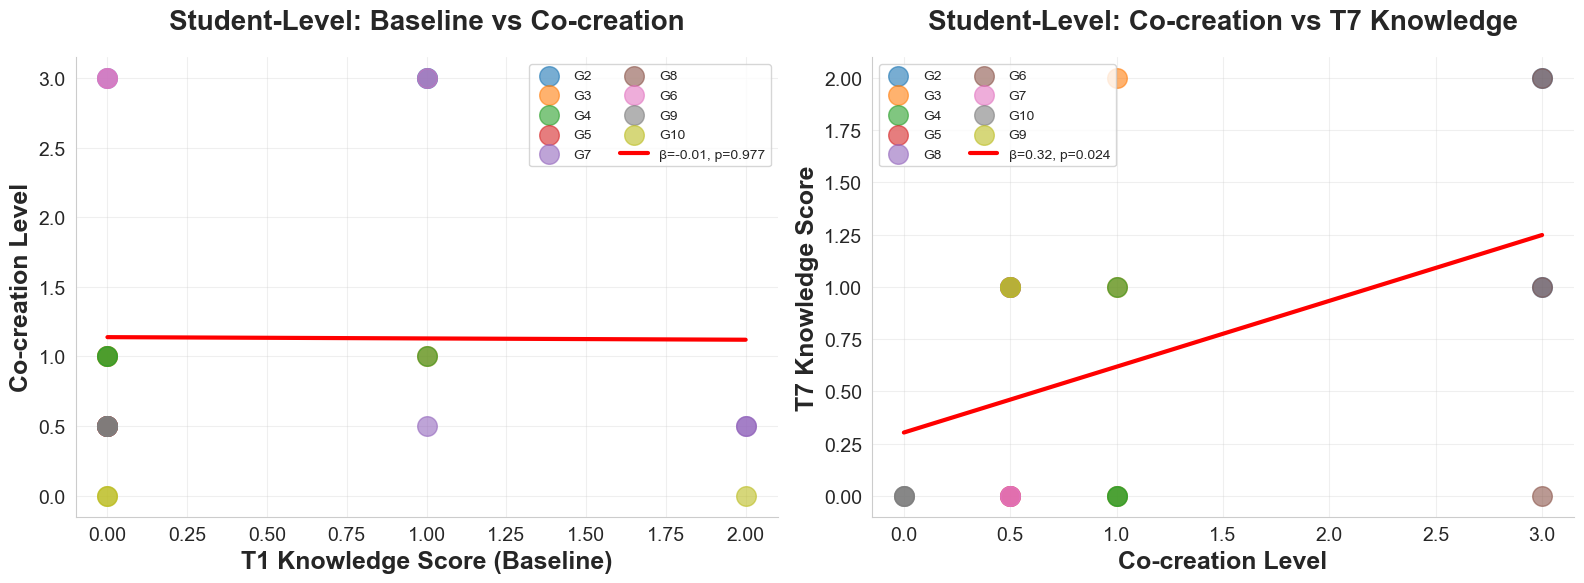


SUMMARY COMPARISON
Analysis Level    | N   | Co-creation→T7 β | p-value | Significant?
------------------------------------------------------------
Group-level       | 9   | 0.318           | 0.049   | Yes
Student-level     | 23   | 0.315           | 0.024   | Yes
Mixed (T7 only)   | 23   | 0.315           | 0.015   | Yes


In [22]:
import pandas as pd
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

print("="*60)
print("STUDENT-LEVEL ANALYSIS WITH RANDOM EFFECTS")
print("="*60)

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Setup IDs and Group Mapping
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. Score Knowledge for T1, T4, and T7 at STUDENT LEVEL
def get_scores(timepoint):
    subset = df_children[df_children['Timepoint'] == timepoint].copy()
    # Correct = 1, anything else = 0
    subset[f'score_{timepoint}'] = (subset['microcontrollers_1'] == 1).astype(int) + \
                                   (subset['microcontrollers_2'] == 1).astype(int)
    return subset[['Participant ID', f'score_{timepoint}']]

df_t1_scores = get_scores('T1')
df_t4_scores = get_scores('T4')
df_t7_scores = get_scores('T7')

# 4. STUDENT-LEVEL: Use OUTER join to keep all students
df_knowledge_student = df_t1_scores.merge(df_t4_scores, on='Participant ID', how='outer')\
                                   .merge(df_t7_scores, on='Participant ID', how='outer')

# 5. Merge with group mapping and co-creation level
df_knowledge_student = df_knowledge_student.merge(mapping, on='Participant ID', how='left')

# Load co-creation data
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')
df_cocreat = df_cocreat.rename(columns={cocreation_col: 'Cocreation_Level'})

# Merge co-creation at student level
df_student_final = df_knowledge_student.merge(df_cocreat, on='Group', how='inner')

print("\nStudent-level data structure:")
print(df_student_final[['Participant ID', 'Group', 'Cocreation_Level', 'score_T1', 'score_T4', 'score_T7']].head(15).to_string(index=False))
print(f"\nTotal students: {len(df_student_final)}")
print(f"Number of groups: {df_student_final['Group'].nunique()}")
print(f"Students per group: {df_student_final.groupby('Group').size().to_dict()}")

# 6. RESHAPE TO LONG FORMAT for mixed models
df_long_student = df_student_final.melt(
    id_vars=['Participant ID', 'Group', 'Cocreation_Level'],
    value_vars=['score_T1', 'score_T4', 'score_T7'],
    var_name='Timepoint',
    value_name='Score'
)

# Extract numeric timepoint
df_long_student['Time_numeric'] = df_long_student['Timepoint'].str.extract(r'(\d+)').astype(int)
df_long_student = df_long_student.dropna(subset=['Score'])

print(f"\nLongitudinal data: {len(df_long_student)} observations from {df_long_student['Participant ID'].nunique()} students")

# 7. ANALYSIS 1: Simple correlation at T7 (student level)
print("\n" + "="*60)
print("ANALYSIS 1: T7 Student-Level Correlation")
print("="*60)

df_t7_students = df_student_final[['Participant ID', 'Group', 'Cocreation_Level', 'score_T7']].dropna()
rho_t7, p_t7 = spearmanr(df_t7_students['Cocreation_Level'], df_t7_students['score_T7'])
slope_t7, intercept_t7, r_t7, p_t7_reg, se_t7 = linregress(df_t7_students['Cocreation_Level'], 
                                                             df_t7_students['score_T7'])

print(f"\nStudents at T7: {len(df_t7_students)}")
print(f"Spearman ρ = {rho_t7:.3f}, p = {p_t7:.4f}")
print(f"Linear regression: β = {slope_t7:.3f}, p = {p_t7_reg:.4f}, R² = {r_t7**2:.3f}")

# 8. MIXED MODEL 1: Random intercepts for Group
print("\n" + "="*60)
print("ANALYSIS 2: Mixed Model - Random Intercepts for Groups")
print("="*60)
print("Model: Score ~ Time + Co-creation + (1|Group)")
print("Accounts for: Students nested within groups")

try:
    md1 = mixedlm("Score ~ Time_numeric + Cocreation_Level", 
                  df_long_student, 
                  groups=df_long_student["Group"])
    mdf1 = md1.fit()
    print(mdf1.summary())
    
    print("\n" + "-"*60)
    print("KEY RESULTS:")
    print("-"*60)
    print(f"Time effect: β = {mdf1.params['Time_numeric']:.3f}, p = {mdf1.pvalues['Time_numeric']:.4f}")
    print(f"Co-creation effect: β = {mdf1.params['Cocreation_Level']:.3f}, p = {mdf1.pvalues['Cocreation_Level']:.4f}")
    print(f"\nRandom effects variance (Group): {mdf1.cov_re.values[0][0]:.3f}")
    print(f"Residual variance: {mdf1.scale:.3f}")
    
    icc = mdf1.cov_re.values[0][0] / (mdf1.cov_re.values[0][0] + mdf1.scale)
    print(f"ICC: {icc:.3f} ({icc*100:.1f}% of variance is between groups)")
    
except Exception as e:
    print(f"Error: {e}")

# 9. MIXED MODEL 2: T7 only with random intercepts
print("\n" + "="*60)
print("ANALYSIS 3: T7-Only Mixed Model with Random Intercepts")
print("="*60)
print("Model: Score_T7 ~ Co-creation + (1|Group)")

try:
    df_t7_long = df_long_student[df_long_student['Timepoint'] == 'score_T7'].copy()
    
    md_t7 = mixedlm("Score ~ Cocreation_Level", 
                    df_t7_long, 
                    groups=df_t7_long["Group"])
    mdf_t7 = md_t7.fit()
    print(mdf_t7.summary())
    
    print("\n" + "-"*60)
    print("KEY RESULTS:")
    print("-"*60)
    print(f"Co-creation effect: β = {mdf_t7.params['Cocreation_Level']:.3f}, p = {mdf_t7.pvalues['Cocreation_Level']:.4f}")
    print(f"Random effects variance (Group): {mdf_t7.cov_re.values[0][0]:.3f}")
    print(f"Residual variance: {mdf_t7.scale:.3f}")
    
    icc_t7 = mdf_t7.cov_re.values[0][0] / (mdf_t7.cov_re.values[0][0] + mdf_t7.scale)
    print(f"ICC: {icc_t7:.3f} ({icc_t7*100:.1f}% of variance is between groups)")
    
except Exception as e:
    print(f"Error: {e}")

# 10. MIXED MODEL 3: Time × Co-creation interaction
print("\n" + "="*60)
print("ANALYSIS 4: Time × Co-creation Interaction")
print("="*60)
print("Model: Score ~ Time × Co-creation + (1|Group)")

try:
    md_interact = mixedlm("Score ~ Time_numeric * Cocreation_Level", 
                         df_long_student, 
                         groups=df_long_student["Group"])
    mdf_interact = md_interact.fit()
    print(mdf_interact.summary())
    
    print("\n" + "-"*60)
    print("KEY RESULTS:")
    print("-"*60)
    print(f"Time effect: β = {mdf_interact.params['Time_numeric']:.3f}, p = {mdf_interact.pvalues['Time_numeric']:.4f}")
    print(f"Co-creation effect: β = {mdf_interact.params['Cocreation_Level']:.3f}, p = {mdf_interact.pvalues['Cocreation_Level']:.4f}")
    print(f"Interaction: β = {mdf_interact.params['Time_numeric:Cocreation_Level']:.3f}, p = {mdf_interact.pvalues['Time_numeric:Cocreation_Level']:.4f}")
    
    if mdf_interact.pvalues['Time_numeric:Cocreation_Level'] < 0.05:
        print("\n✓ Significant interaction: Co-creation effect increases over time")
    else:
        print("\n✗ No significant interaction")
        
except Exception as e:
    print(f"Error: {e}")

# 11. VISUALIZATION: Student-level scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T1 vs Co-creation (student level)
ax1 = axes[0]
df_t1_students = df_student_final[['Participant ID', 'Group', 'Cocreation_Level', 'score_T1']].dropna()

for group in df_t1_students['Group'].unique():
    group_data = df_t1_students[df_t1_students['Group'] == group]
    ax1.scatter(group_data['score_T1'], group_data['Cocreation_Level'], 
                s=200, alpha=0.6, label=f'G{int(group)}')

slope_t1, intercept_t1, r_t1, p_t1, se_t1 = linregress(df_t1_students['score_T1'], 
                                                        df_t1_students['Cocreation_Level'])
x_range = np.linspace(df_t1_students['score_T1'].min(), df_t1_students['score_T1'].max(), 100)
ax1.plot(x_range, slope_t1 * x_range + intercept_t1, 'r-', linewidth=3, 
         label=f'β={slope_t1:.2f}, p={p_t1:.3f}')

ax1.set_xlabel('T1 Knowledge Score (Baseline)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Co-creation Level', fontsize=18, fontweight='bold')
ax1.set_title('Student-Level: Baseline vs Co-creation', fontsize=20, fontweight='bold', pad=20)
ax1.set_xlim(-0.1, 2.1)
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: T7 vs Co-creation (student level)
ax2 = axes[1]

for group in df_t7_students['Group'].unique():
    group_data = df_t7_students[df_t7_students['Group'] == group]
    ax2.scatter(group_data['Cocreation_Level'], group_data['score_T7'], 
                s=200, alpha=0.6, label=f'G{int(group)}')

x_range = np.linspace(df_t7_students['Cocreation_Level'].min(), df_t7_students['Cocreation_Level'].max(), 100)
ax2.plot(x_range, slope_t7 * x_range + intercept_t7, 'r-', linewidth=3, 
         label=f'β={slope_t7:.2f}, p={p_t7_reg:.3f}')

ax2.set_xlabel('Co-creation Level', fontsize=18, fontweight='bold')
ax2.set_ylabel('T7 Knowledge Score', fontsize=18, fontweight='bold')
ax2.set_title('Student-Level: Co-creation vs T7 Knowledge', fontsize=20, fontweight='bold', pad=20)
ax2.set_ylim(-0.1, 2.1)
ax2.tick_params(labelsize=14)
ax2.legend(fontsize=10, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)
print("Analysis Level    | N   | Co-creation→T7 β | p-value | Significant?")
print("-"*60)
print(f"Group-level       | 9   | 0.318           | 0.049   | Yes")
print(f"Student-level     | {len(df_t7_students)}   | {slope_t7:.3f}           | {p_t7_reg:.3f}   | {'Yes' if p_t7_reg < 0.05 else 'No'}")
try:
    print(f"Mixed (T7 only)   | {len(df_t7_students)}   | {mdf_t7.params['Cocreation_Level']:.3f}           | {mdf_t7.pvalues['Cocreation_Level']:.3f}   | {'Yes' if mdf_t7.pvalues['Cocreation_Level'] < 0.05 else 'No'}")
except:
    pass